# TPC raw ADC → IBF and primary-density maps

This notebook starts from the native per-sector/per-module histograms produced by
`PHGarfieldRawHitsQA`:

`h_adc_pad_vs_layer_side{side}_sec{sector:02d}_R{module}_{QA_NAME}`

It is intentionally split into two independent parts.

## Part I — IBF
1. Load native `pad × layer` maps.
2. Detect vertical dead FEE regions wider than a configurable number of pads.
3. Detect full- and half-sector dead horizontal stripes.
4. Repair only **inside each sector**; sector gaps are never bridged.
5. Optionally suppress SAMPA/pad outliers using raw, sum, mean, median, or trimmed mean.
6. Convert cleaned ADC to an areal-density proxy using `r*dphi*dr`.
7. Smoothly extrapolate R1 inward to the 21 cm inner field cage.
8. Build side-0 and side-1 `rho(r,phi)` maps and diagnostic 2D fits.

## Part II — primary density
Starts again from the cleaned ADC map, optionally divides by a gain map, and makes
the same `r`, `phi`, and 2D-fit diagnostics.

For now `N_EVENTS = 1`. The absolute IBF scale is deliberately left free for later
PHGarfield/data tuning with distortion observables such as rDCA.


In [1]:
import ROOT as root
import numpy as np
import math
import os
import subprocess
from array import array
from pathlib import Path
import matplotlib.pyplot as plt

from scipy import ndimage
from scipy.optimize import least_squares

root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)

# ============================================================
# USER CONFIGURATION
# ============================================================

INPUT_ROOT = os.environ.get("TPC_DENSITY_INPUT", "input/tpc_poly_track_HITS_ppFieldOn_795130_qa_v2.root")
RUN_TAG = os.environ.get("TPC_DENSITY_TAG", "")
IS_BATCH_CHILD = os.environ.get("TPC_DENSITY_BATCH_CHILD", "0") == "1"
QA_NAME = "PHGarfieldRawHitsQA"
N_EVENTS = 1.0

OUTPUT_DIR = Path(os.environ.get("TPC_DENSITY_OUTPUT_DIR", "output"))
OUTPUT_SUFFIX = f"_{RUN_TAG}" if RUN_TAG else ""
QA_PLOT_DIR = OUTPUT_DIR / f"qa_plots{OUTPUT_SUFFIX}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QA_PLOT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_ROOT = OUTPUT_DIR / f"TPC_IBF_primary_maps{OUTPUT_SUFFIX}.root"
QA_ROOT = OUTPUT_DIR / f"TPC_IBF_primary_QA{OUTPUT_SUFFIX}.root"

N_SIDES = 2
N_SECTORS = 12
N_MODULES = 3
LAYERS_PER_MODULE = 16
N_PADS = [94, 128, 192]

MIN_RADII_MODULE_MM = [314.9835971194212, 416.5920253621078, 589.1096334932404]
DELTA_RADII_MODULE_MM = [5.657908935192669, 10.206891263554285, 10.970474549405283]
AVR_DPHI_MODULE = [0.005307305707805798, 0.003959159565794228, 0.0026514278029726376]
AVR_MINPHI_MODULE = [1.3219316149976348, 1.3179398673058638, 1.3175593270455]

USE_IDEAL_PAD_MAP = True
IDEAL_PAD_MAP_LIBRARY = "libtpctrackreco.so"

IFC_RADIUS_CM = 21.0

# ------------------------------------------------------------------
# DEAD / HOT CHANNEL AND FEE / STRIPE DETECTION
# ------------------------------------------------------------------
DEAD_CELL_REL_THRESHOLD = 0.18

# FEE = vertical multi-pad region. Small alive islands inside a dead FEE are
# allowed; only genuinely dead-like cells in the FEE region are reconstructed.
MIN_DEAD_FEE_WIDTH = 2
DEAD_FEE_LAYER_FRACTION = 0.45
FEE_BRIDGE_PADS = 2
FEE_CONTEXT_PADS = 12

# Dead stripes are detector/readout structure and are treated separately:
# R1/R2: normally full-sector layer-wide stripe
# R3: allow half-sector stripe as well as full-sector stripe
STRIPE_REL_THRESHOLD = 0.28
FULL_STRIPE_FRACTION = 0.70
HALF_STRIPE_FRACTION = 0.70
OTHER_HALF_MAX_DEAD_FRACTION = 0.35
STRIPE_NEIGHBOR_LAYERS = 3
ALLOW_R3_HALF_STRIPES = True

# Larger irregular dead blocks
MIN_DEAD_BLOCK_WIDTH = 2
MIN_DEAD_BLOCK_LAYERS = 2
MIN_DEAD_BLOCK_CELLS = 6
BLOCK_CONTEXT_PADS = 12
BLOCK_CONTEXT_LAYERS = 3

# Single-cell/pad outliers. This operates only inside each native sector, so
# physical sector boundaries are never crossed.
REPAIR_SINGLE_OUTLIERS = True
SINGLE_DEAD_FACTOR = 0.25
SINGLE_HOT_FACTOR = 2.5
SINGLE_OUTLIER_PAD_RADIUS = 2
SINGLE_OUTLIER_LAYER_RADIUS = 1
SINGLE_OUTLIER_MIN_NEIGHBORS = 5
SINGLE_OUTLIER_PASSES = 2

# Final robust physical smoothing, still sector-local. A local trimmed mean/median
# suppresses small fluctuations but preserves broad GEM structures.
SMOOTH_NATIVE_MAPS = True
SMOOTH_PAD_RADIUS = 2
SMOOTH_LAYER_RADIUS = 1
SMOOTH_BLEND = 0.75

# IBF keeps the measured dead stripes. Underlying clean maps used for
# extrapolation and the default primary map reconstruct those stripes first.
KEEP_DEAD_STRIPES_IN_IBF = True
SAVE_PRIMARY_WITH_DEAD_STRIPES = True

# ------------------------------------------------------------------
# PAD/SAMPA ESTIMATOR
# ------------------------------------------------------------------
# "raw", "sum", "mean", "median", "trimmed_mean"
ADC_ESTIMATOR = "trimmed_mean"
TRIM_FRACTION = 0.15
CLIP_OUTLIERS = True
CLIP_NSIGMA = 5.0

GLOBAL_PHI_BINS = 720
PHI_MIN = -math.pi
PHI_MAX = math.pi

# ------------------------------------------------------------------
# SAFE POWER-LAW EXTRAPOLATION TO 21 cm
# rho(r,phi) = A(phi)/r^alpha
# Used independently for IBF and primary.
# ------------------------------------------------------------------
ALPHA_INITIAL = 1.5
ALPHA_BOUNDS = (0.8, 2.7)
N_R1_FIT_LAYERS = 12
N_INNER_EXTRAP_BINS = 24

ALPHA_LOSS = "soft_l1"
ALPHA_F_SCALE = 1.0
MIN_PHI_BINS_PER_R_LAYER = 30
MIN_HEALTHY_FRACTION_FOR_ALPHA = 0.35

N_R1_AMPLITUDE_LAYERS = 16
MIN_POINTS_FOR_PHI_AMPLITUDE = 12
MIN_R1_COVERAGE_LAYERS = 2

# ---------------------------------------------------------------
# phi dependence of the INNER extrapolation
# ---------------------------------------------------------------
# IMPORTANT: the model is parameterized at a reference radius:
#
#   rho(r,phi) = rho_ref(phi) * (R_REF / r)^alpha(phi)
#
# This keeps rho_ref(phi) in density units even when alpha varies with phi.
# The old A(phi)/r^alpha parameterization made A change units with alpha and
# could create artificial factor-of-10 structure.
R_REF_CM = None                  # strongly recommended: first measured R1 radius

# alpha(phi) is intentionally extracted with MUCH coarser phi binning than
# the final density map. 36 bins = 10 degrees/bin = 3 bins/sector.
ALPHA_N_PHI_BINS = 4
ALPHA_LOW_HARMONIC = 0

# Three alpha QA models:
#   constant     : one alpha for the whole side
#   coarse       : coarse robust alpha(phi), interpolated to fine phi
#   lowharmonic  : robust n<=4 fit to the coarse values
ALPHA_PHI_FINAL = "lowharmonic"
MIN_R1_POINTS_PER_ALPHA_BIN = 8

# rho_ref(phi) / multiplicity models:
#   binwise       : robust value in every fine phi bin
#   sector_smooth : robust smoothing INSIDE each physical sector only
#   highharmonic  : optional global high-order Fourier comparison
RHOREF_PHI_FINAL = "sector_smooth"
RHOREF_SECTOR_MEDIAN_WINDOW = 21
RHOREF_SECTOR_GAUSS_SIGMA = 3.0

# After requiring >=10 R1 measurements per fine phi bin, some bins can still be
# missing because pad centers move slightly with radius. Fill those missing values
# only by interpolation INSIDE the same physical sector.
RHOREF_FILL_MISSING_WITHIN_SECTOR = True
RHOREF_HIGH_HARMONIC = 24

# ------------------------------------------------------------------
# Radial damping of phi modulation below the first measured R1 layer
# ------------------------------------------------------------------
# rho_ref(phi) is decomposed into mean + modulation. The modulation can
# gradually fade toward the IFC while the radial 1/r^alpha behavior is kept.
#
# Values below mean the fraction of phi modulation retained at r=IFC:
#   1.0 -> preserve full measured phi structure all the way inward
#   0.5 -> keep half of it at the IFC
#   0.0 -> become phi-flat at the IFC
PHI_MODULATION_IFC_FRACTIONS = [1.0, 0.5, 0.0]
PHI_MODULATION_IFC_FINAL = 0.5

# "linear" gives S(r) = f_IFC + (1-f_IFC)*(r-IFC)/(R_first-IFC)
PHI_MODULATION_DAMPING = "linear"

ALLOW_EXTERNAL_R_REF = False

# ------------------------------------------------------------------
# Smooth diagnostic 2D fit
# ------------------------------------------------------------------
FOURIER_ORDER = 12
RADIAL_POLY_ORDER = 3
FIT_MIN_DENSITY = 0.0
ROBUST_2D_FIT = True
ROBUST_2D_LOSS = "soft_l1"

# ------------------------------------------------------------------
# Gain map / primary density
# ------------------------------------------------------------------
GAIN_MAP_FILE = "../distort/input/layer_gain_79513_Mariia_side01.root"

GAIN_MAP_HIST_SIDE0 = "hGainMap_side0_South"
GAIN_MAP_HIST_SIDE1 = "hGainMap_side1_North"

# Gain histogram axes from the supplied ROOT file:
# x = sector 0..11, y = TPC layer index 0..47.
# Raw-hit TPC layers are 7..54.
GAIN_LAYER_OFFSET = 7

PRIMARY_DIVIDE_BY_GAIN = True



# ------------------------------------------------------------------
# OPTIONAL MULTI-FILE BATCH
# ------------------------------------------------------------------
# Leave empty for normal interactive use. To process several runs, put the
# input ROOT files here and call run_batch() in the final notebook cell.

BATCH_INPUT_ROOTS = [#QA_79514.root  QA_79515.root  QA_79516.root  QA_79526.root  QA_79528.root  QA_79529.root
    "input/qa/QA1_79513.root",
    "input/qa/QA1_79507.root",
    "input/qa/QA1_79514.root",
    "input/qa/QA1_79515.root",
    "input/qa/QA1_79516.root",
    "input/qa/QA1_79526.root",
    "input/qa/QA1_79528.root",
    "input/qa/QA1_79529.root"
]
NOTEBOOK_FILE = Path("TPC_IBF_PrimaryDensity_Extraction_v12.ipynb")

print("Configuration loaded")
print("Input:", INPUT_ROOT)
print("Gain map:", GAIN_MAP_FILE)
print("Output ROOT:", OUTPUT_ROOT)
print("QA ROOT:", QA_ROOT)


Welcome to JupyROOT 6.30/06
Configuration loaded
Input: input/tpc_poly_track_HITS_ppFieldOn_795130_qa_v2.root
Gain map: ../distort/input/layer_gain_79513_Mariia_side01.root
Output ROOT: output/TPC_IBF_primary_maps.root
QA ROOT: output/TPC_IBF_primary_QA.root


## Geometry and ROOT helpers

Dead-region finding is performed in native sector coordinates. The conversion to
global `(r,phi)` happens only after repair.

This version first tries to load the same `IdealPadMap` used by
`PHGarfieldRawHitsQA`. If available, it uses exact `get_radius(layer)` and
`get_phi(side,sector,layer,local_pad)` values. This is especially important for
the sector that crosses `phi = +/-pi`: its pad centers are unwrapped only while
calculating `dphi`, then wrapped back to `[-pi,pi)` for histogram filling.

The supplied average geometry is retained only as a fallback.


In [2]:
def get_hist_name(side, sector, module):
    return f"h_adc_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}_{QA_NAME}"

def th2_to_numpy(h):
    nx, ny = h.GetNbinsX(), h.GetNbinsY()
    z = np.empty((ny, nx), dtype=float)
    for iy in range(ny):
        for ix in range(nx):
            z[iy, ix] = h.GetBinContent(ix+1, iy+1)
    x = np.array([h.GetXaxis().GetBinCenter(i+1) for i in range(nx)])
    y = np.array([h.GetYaxis().GetBinCenter(i+1) for i in range(ny)])
    return z, x, y

# ------------------------------------------------------------
# Exact IdealPadMap geometry when available
# ------------------------------------------------------------
ideal_pad_map = None

if USE_IDEAL_PAD_MAP:
    try:
        root.gSystem.Load(IDEAL_PAD_MAP_LIBRARY)
        if hasattr(root, "IdealPadMap"):
            ideal_pad_map = root.IdealPadMap()
            if (not ideal_pad_map.is_loaded()) and ideal_pad_map.load_from_cdb(0) != 0:
                print("WARNING: IdealPadMap CDB load failed; using fallback geometry")
                ideal_pad_map = None
        else:
            print("WARNING: ROOT.IdealPadMap is unavailable; using fallback geometry")
    except Exception as exc:
        print("WARNING: could not initialize IdealPadMap:", exc)
        ideal_pad_map = None

print("Geometry source:", "IdealPadMap" if ideal_pad_map is not None else "fallback averages")

def global_layer(module, local_layer):
    return 7 + 16*module + local_layer

def module_layer_radii_cm(module):
    if ideal_pad_map is not None:
        return np.array([
            float(ideal_pad_map.get_radius(global_layer(module, il)))
            for il in range(LAYERS_PER_MODULE)
        ])
    r0 = MIN_RADII_MODULE_MM[module] / 10.0
    dr = DELTA_RADII_MODULE_MM[module] / 10.0
    return r0 + dr*(np.arange(LAYERS_PER_MODULE)+0.5)

def module_layer_dr_cm(module):
    r = module_layer_radii_cm(module)
    # Voronoi-like radial width around layer centers, bounded by midpoint.
    e = np.empty(len(r)+1)
    e[1:-1] = 0.5*(r[:-1]+r[1:])
    e[0] = r[0] - 0.5*(r[1]-r[0])
    e[-1] = r[-1] + 0.5*(r[-1]-r[-2])
    return np.diff(e)

def wrap_phi(phi):
    return (phi + np.pi) % (2*np.pi) - np.pi

def sector_phi_centers(module, sector, local_layer, side=0):
    npads = N_PADS[module]

    if ideal_pad_map is not None:
        layer = global_layer(module, local_layer)
        vals = [
            float(ideal_pad_map.get_phi(side, sector, layer, local_pad))
            for local_pad in range(npads)
        ]
        return np.array([wrap_phi(v) for v in vals], dtype=float)

    dphi = AVR_DPHI_MODULE[module]
    sector_pitch = 2*np.pi/12.0
    phi0 = AVR_MINPHI_MODULE[module] + sector*sector_pitch
    return wrap_phi(phi0 + (np.arange(npads)+0.5)*dphi)

def layer_dphi(module, local_layer, side=0, sector=0):
    ph = sector_phi_centers(module, sector, local_layer, side)
    # unwrap before taking differences; this is important for the sector
    # that crosses +/-pi.
    pu = np.unwrap(ph)
    if len(pu) < 2:
        return AVR_DPHI_MODULE[module]
    return float(np.median(np.abs(np.diff(pu))))

def pad_area_cm2(module, local_layer, side=0):
    r = module_layer_radii_cm(module)[local_layer]
    dr = module_layer_dr_cm(module)[local_layer]
    dphi = layer_dphi(module, local_layer, side)
    return r * dphi * dr

def robust_scale(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0
    med = np.median(x)
    mad = np.median(np.abs(x-med))
    return 1.4826*mad if mad > 0 else np.std(x)

def clipped_values(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return x
    med = np.median(x)
    sig = robust_scale(x)
    if sig <= 0 or not np.isfinite(sig):
        return x
    return x[np.abs(x-med) <= CLIP_NSIGMA*sig]

def estimate_values(x, mode=None):
    if mode is None:
        mode = ADC_ESTIMATOR
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan

    if mode == "sum":
        return np.sum(x)
    if mode == "raw":
        return np.mean(x)

    if CLIP_OUTLIERS:
        xc = clipped_values(x)
        if xc.size:
            x = xc

    if mode == "mean":
        return np.mean(x)
    if mode == "median":
        return np.median(x)
    if mode == "trimmed_mean":
        xs = np.sort(x)
        ntrim = int(TRIM_FRACTION*len(xs))
        if 2*ntrim >= len(xs):
            return np.median(xs)
        return np.mean(xs[ntrim:len(xs)-ntrim])

    raise ValueError(mode)

def weighted_median(values, weights):
    values = np.asarray(values, float)
    weights = np.asarray(weights, float)
    good = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(good):
        return np.nan
    v = values[good]
    w = weights[good]
    order = np.argsort(v)
    v = v[order]
    w = w[order]
    c = np.cumsum(w)
    return v[np.searchsorted(c, 0.5*c[-1])]


Geometry source: fallback averages


Error in <TUnixSystem::FindDynamicLibrary>: libtpctrackreco.so does not exist in /home/yoren/bnl/ROOT/install/lib:.:/home/yoren/bnl/ROOT/install/lib:/lib/x86_64-linux-gnu/glibc-hwcaps/x86-64-v3:/lib/x86_64-linux-gnu/glibc-hwcaps/x86-64-v2:/lib/x86_64-linux-gnu/tls/haswell/x86_64:/lib/x86_64-linux-gnu/tls/haswell:/lib/x86_64-linux-gnu/tls/x86_64:/lib/x86_64-linux-gnu/tls:/lib/x86_64-linux-gnu/haswell/x86_64:/lib/x86_64-linux-gnu/haswell:/lib/x86_64-linux-gnu/x86_64:/lib/x86_64-linux-gnu:/usr/lib/x86_64-linux-gnu/glibc-hwcaps/x86-64-v3:/usr/lib/x86_64-linux-gnu/glibc-hwcaps/x86-64-v2:/usr/lib/x86_64-linux-gnu/tls/haswell/x86_64:/usr/lib/x86_64-linux-gnu/tls/haswell:/usr/lib/x86_64-linux-gnu/tls/x86_64:/usr/lib/x86_64-linux-gnu/tls:/usr/lib/x86_64-linux-gnu/haswell/x86_64:/usr/lib/x86_64-linux-gnu/haswell:/usr/lib/x86_64-linux-gnu/x86_64:/usr/lib/x86_64-linux-gnu:/lib/glibc-hwcaps/x86-64-v3:/lib/glibc-hwcaps/x86-64-v2:/lib/tls/haswell/x86_64:/lib/tls/haswell:/lib/tls/x86_64:/lib/tls:/lib/

# Part I — IBF source shape

## 1. Load native sector/module maps

In [3]:
fin = root.TFile.Open(INPUT_ROOT, "READ")
if not fin or fin.IsZombie():
    raise OSError(f"Cannot open {INPUT_ROOT}")

raw_maps = {}
missing = []

for side in range(N_SIDES):
    for module in range(N_MODULES):
        for sector in range(N_SECTORS):
            name = get_hist_name(side, sector, module)
            h = fin.Get(name)
            if not h:
                missing.append(name)
                continue
            z, pads, layers = th2_to_numpy(h)
            raw_maps[(side,module,sector)] = {
                "adc": z/N_EVENTS,
                "pads": pads,
                "layers": layers,
                "name": name,
            }

print(f"Loaded {len(raw_maps)} maps")
if missing:
    print(f"Missing {len(missing)} histograms")
    print("\n".join(missing[:10]))


Loaded 72 maps


## 2. Automatic defect masks

The native sector maps are classified before any smoothing:

- **dead FEE:** vertical multi-pad regions, allowing small live islands inside;
- **dead stripe:** a radial layer that is strongly suppressed relative to its neighboring layers;
- **dead block:** larger irregular connected dead regions;
- **single hot/dead cells:** handled later by a local robust outlier pass.

Dead stripes are special. They are reconstructed for the underlying physical source
used by extrapolation and primary-density extraction, but they are restored to their
measured dead values in the final IBF map.


In [4]:
def contiguous_true_regions(mask):
    mask=np.asarray(mask,bool)
    out=[]; start=None
    for i,v in enumerate(mask):
        if v and start is None: start=i
        elif not v and start is not None:
            out.append((start,i)); start=None
    if start is not None: out.append((start,len(mask)))
    return out

def robust_dead_cell_candidates(adc):
    adc=np.asarray(adc,float)
    pos=np.where(np.isfinite(adc) & (adc>0),adc,np.nan)
    row=np.nanmedian(pos,axis=1); col=np.nanmedian(pos,axis=0); glob=np.nanmedian(pos)
    row=np.where(np.isfinite(row),row,glob); col=np.where(np.isfinite(col),col,glob)
    expected=np.maximum(row[:,None],col[None,:])
    candidate=(~np.isfinite(adc)) | (np.isfinite(expected) & (expected>0) &
                                    (adc<DEAD_CELL_REL_THRESHOLD*expected))
    return candidate,expected

def radial_dead_fraction(adc,il):
    """Dead fraction of one layer relative to nearby radial layers, pad-by-pad."""
    rows=[j for d in range(1,STRIPE_NEIGHBOR_LAYERS+1)
          for j in (il-d,il+d) if 0<=j<adc.shape[0]]
    if not rows: return np.zeros(adc.shape[1],bool)
    ref=np.nanmedian(np.where(np.asarray(adc[rows])>0,adc[rows],np.nan),axis=0)
    return (~np.isfinite(adc[il])) | (np.isfinite(ref) & (ref>0) &
                                      (adc[il]<STRIPE_REL_THRESHOLD*ref))

def detect_dead_structures(adc,module):
    candidate,expected=robust_dead_cell_candidates(adc)
    nlayer,npad=adc.shape; mid=npad//2

    # FEE columns: bridge one/two alive columns inside an otherwise dead vertical FEE.
    colfrac=np.mean(candidate,axis=0)
    fee_cols=colfrac>=DEAD_FEE_LAYER_FRACTION
    if FEE_BRIDGE_PADS>0:
        fee_cols=ndimage.binary_closing(fee_cols,structure=np.ones(2*FEE_BRIDGE_PADS+1))
    fee_regions=[x for x in contiguous_true_regions(fee_cols) if x[1]-x[0]>=MIN_DEAD_FEE_WIDTH]
    fee_region_mask=np.zeros_like(candidate)
    for lo,hi in fee_regions: fee_region_mask[:,lo:hi]=True

    # Only low cells inside the region are repaired; live islands are retained.
    fee_mask=fee_region_mask & candidate

    stripe_full=np.zeros_like(candidate)
    stripe_half=np.zeros_like(candidate)
    stripe_details=[]

    for il in range(nlayer):
        dead=radial_dead_fraction(adc,il)
        usable=~fee_region_mask[il]
        if np.count_nonzero(usable)<4: continue

        frac=np.count_nonzero(dead & usable)/np.count_nonzero(usable)
        if frac>=FULL_STRIPE_FRACTION:
            stripe_full[il,usable]=True
            stripe_details.append(("full",il,float(frac)))
            continue

        if module==2 and ALLOW_R3_HALF_STRIPES:
            left=usable[:mid]; right=usable[mid:]
            lf=np.count_nonzero(dead[:mid] & left)/max(np.count_nonzero(left),1)
            rf=np.count_nonzero(dead[mid:] & right)/max(np.count_nonzero(right),1)
            if lf>=HALF_STRIPE_FRACTION and rf<=OTHER_HALF_MAX_DEAD_FRACTION:
                stripe_half[il,:mid]=left
                stripe_details.append(("half-left",il,float(lf)))
            elif rf>=HALF_STRIPE_FRACTION and lf<=OTHER_HALF_MAX_DEAD_FRACTION:
                stripe_half[il,mid:]=right
                stripe_details.append(("half-right",il,float(rf)))

    # Irregular dead blocks, excluding already-classified FEE/stripe structure.
    already=fee_mask | stripe_full | stripe_half
    remaining=candidate & ~already
    labels,nlab=ndimage.label(remaining,structure=np.ones((3,3),int))
    block=np.zeros_like(candidate); details=[]
    for lab in range(1,nlab+1):
        yy,xx=np.where(labels==lab)
        if not len(xx): continue
        width=xx.max()-xx.min()+1; height=yy.max()-yy.min()+1
        if width>=MIN_DEAD_BLOCK_WIDTH and height>=MIN_DEAD_BLOCK_LAYERS and len(xx)>=MIN_DEAD_BLOCK_CELLS:
            block[yy,xx]=True
            details.append((int(yy.min()),int(yy.max()+1),int(xx.min()),int(xx.max()+1),int(len(xx))))

    return {"candidate":candidate,"expected":expected,"fee":fee_mask,
            "fee_regions":fee_regions,"fee_region_mask":fee_region_mask,
            "stripe_full":stripe_full,"stripe_half":stripe_half,
            "stripe":stripe_full|stripe_half,"stripe_details":stripe_details,
            "block":block,"block_details":details,"col_dead_fraction":colfrac}

auto_masks={key:detect_dead_structures(item["adc"],key[1]) for key,item in raw_maps.items()}

print("Dead-FEE regions:",sum(len(v["fee_regions"]) for v in auto_masks.values()))
print("Dead stripes:",sum(len(v["stripe_details"]) for v in auto_masks.values()))
print("Large dead blocks:",sum(len(v["block_details"]) for v in auto_masks.values()))


/tmp/ipykernel_64145/1002375550.py:14: RuntimeWarning: All-NaN slice encountered
  row=np.nanmedian(pos,axis=1); col=np.nanmedian(pos,axis=0); glob=np.nanmedian(pos)
/tmp/ipykernel_64145/1002375550.py:26: RuntimeWarning: All-NaN slice encountered
  ref=np.nanmedian(np.where(np.asarray(adc[rows])>0,adc[rows],np.nan),axis=0)


Dead-FEE regions: 35
Dead stripes: 78
Large dead blocks: 120


### Optional manual corrections

In [5]:
# Zero-based side/module/sector/local-layer/local-pad indices.
MANUAL_DEAD_FEE = [
    # (side, module, sector, first_pad, last_pad_exclusive)
]
MANUAL_FULL_STRIPE = [
    # (side, module, sector, local_layer)
]
MANUAL_HALF_STRIPE = [
    # (side, module, sector, local_layer, "left" or "right")
]
MANUAL_DEAD_BLOCK = [
    # (side, module, sector, layer_lo, layer_hi, pad_lo, pad_hi)
]

for side,module,sector,lo,hi in MANUAL_DEAD_FEE:
    key=(side,module,sector)
    auto_masks[key]["fee"][:,lo:hi] = True
    auto_masks[key]["fee_regions"].append((lo,hi))

for side,module,sector,il in MANUAL_FULL_STRIPE:
    key=(side,module,sector)
    valid=~auto_masks[key]["fee"][il]
    auto_masks[key]["stripe_full"][il,valid]=True

for side,module,sector,il,which in MANUAL_HALF_STRIPE:
    key=(side,module,sector)
    npad=raw_maps[key]["adc"].shape[1]
    mid=npad//2
    if which=="left":
        auto_masks[key]["stripe_half"][il,:mid]=True
    elif which=="right":
        auto_masks[key]["stripe_half"][il,mid:]=True
    else:
        raise ValueError(which)

for side,module,sector,l0,l1,p0,p1 in MANUAL_DEAD_BLOCK:
    key=(side,module,sector)
    auto_masks[key]["block"][l0:l1,p0:p1]=True


## 3. Recover the underlying physical source

The reconstruction now produces two native maps per sector:

- `model_clean_maps`: FEE, blocks, single dead/hot cells, and stripes are recovered;
  this map is robustly smoothed and is used for extrapolation and primary density.
- `ibf_native_maps`: starts from the same clean physical source, then restores the
  measured dead stripes. This is the final measured IBF behavior.

A FEE repair changes only dead-like cells inside the FEE region, so a few live
channels in the middle of a damaged FEE are not overwritten. All smoothing is done
inside one native sector and therefore cannot blur across a sector boundary.


In [6]:
def local_robust_value(arr,il,ip,pad_radius,layer_radius,exclude=None):
    vals=[]
    for jl in range(max(0,il-layer_radius),min(arr.shape[0],il+layer_radius+1)):
        for jp in range(max(0,ip-pad_radius),min(arr.shape[1],ip+pad_radius+1)):
            if jl==il and jp==ip: continue
            if exclude is not None and exclude[jl,jp]: continue
            v=arr[jl,jp]
            if np.isfinite(v) and v>0: vals.append(v)
    return estimate_values(vals,"trimmed_mean") if len(vals)>=SINGLE_OUTLIER_MIN_NEIGHBORS else np.nan

def repair_fee_regions(adc,fee_mask,fee_regions,protected):
    out=adc.copy().astype(float)
    for lo,hi in fee_regions:
        for il,ip in zip(*np.where(fee_mask[:,lo:hi])):
            ip+=lo
            left=[out[il,p] for p in range(max(0,lo-FEE_CONTEXT_PADS),lo)
                  if not protected[il,p] and np.isfinite(out[il,p]) and out[il,p]>0]
            right=[out[il,p] for p in range(hi,min(out.shape[1],hi+FEE_CONTEXT_PADS))
                   if not protected[il,p] and np.isfinite(out[il,p]) and out[il,p]>0]
            lv=estimate_values(left,"trimmed_mean"); rv=estimate_values(right,"trimmed_mean")
            if np.isfinite(lv) and np.isfinite(rv):
                t=(ip-lo+1)/(hi-lo+1); out[il,ip]=(1-t)*lv+t*rv
            elif np.isfinite(lv): out[il,ip]=lv
            elif np.isfinite(rv): out[il,ip]=rv
    return out

def repair_mask_from_context(adc,mask,protected):
    out=adc.copy().astype(float)
    for il,ip in zip(*np.where(mask)):
        v=local_robust_value(out,il,ip,BLOCK_CONTEXT_PADS,BLOCK_CONTEXT_LAYERS,protected|mask)
        if np.isfinite(v): out[il,ip]=v
    return out

def recover_stripes(adc,stripe_mask,other_bad):
    out=adc.copy().astype(float)
    for il,ip in zip(*np.where(stripe_mask)):
        vals=[]
        for d in range(1,STRIPE_NEIGHBOR_LAYERS+1):
            for jl in (il-d,il+d):
                if 0<=jl<out.shape[0] and not other_bad[jl,ip]:
                    v=out[jl,ip]
                    if np.isfinite(v) and v>0: vals.append(v)
        if vals: out[il,ip]=estimate_values(vals,"trimmed_mean")
        else:
            v=local_robust_value(out,il,ip,2,STRIPE_NEIGHBOR_LAYERS,other_bad|stripe_mask)
            if np.isfinite(v): out[il,ip]=v
    return out

def repair_single_outliers(adc,protected):
    out=adc.copy().astype(float)
    for _ in range(SINGLE_OUTLIER_PASSES):
        new=out.copy(); changed=0
        for il in range(out.shape[0]):
            for ip in range(out.shape[1]):
                if protected[il,ip]: continue
                ref=local_robust_value(out,il,ip,SINGLE_OUTLIER_PAD_RADIUS,
                                       SINGLE_OUTLIER_LAYER_RADIUS,protected)
                if not np.isfinite(ref) or ref<=0: continue
                v=out[il,ip]
                bad=(not np.isfinite(v)) or v<=0 or v<SINGLE_DEAD_FACTOR*ref or v>SINGLE_HOT_FACTOR*ref
                if bad:
                    new[il,ip]=ref; changed+=1
        out=new
        if changed==0: break
    return out

def robust_smooth_native(adc):
    if not SMOOTH_NATIVE_MAPS: return adc.copy()
    out=adc.copy().astype(float); sm=out.copy()
    for il in range(out.shape[0]):
        for ip in range(out.shape[1]):
            vals=[]
            for jl in range(max(0,il-SMOOTH_LAYER_RADIUS),min(out.shape[0],il+SMOOTH_LAYER_RADIUS+1)):
                for jp in range(max(0,ip-SMOOTH_PAD_RADIUS),min(out.shape[1],ip+SMOOTH_PAD_RADIUS+1)):
                    v=out[jl,jp]
                    if np.isfinite(v) and v>0: vals.append(v)
            ref=estimate_values(vals,"trimmed_mean")
            if np.isfinite(ref):
                sm[il,ip]=(1.0-SMOOTH_BLEND)*out[il,ip]+SMOOTH_BLEND*ref
    return sm

model_clean_maps={}
ibf_native_maps={}
primary_stripe_native_maps={}
repair_masks={}
stripe_masks={}

for key,item in raw_maps.items():
    m=auto_masks[key]
    raw=item["adc"].astype(float)
    stripe=m["stripe"]
    other_bad=m["fee"]|m["block"]

    a=repair_fee_regions(raw,m["fee"],m["fee_regions"],stripe|m["block"])
    a=repair_mask_from_context(a,m["block"],stripe|m["fee"])
    a=recover_stripes(a,stripe,other_bad)
    if REPAIR_SINGLE_OUTLIERS: a=repair_single_outliers(a,np.zeros_like(stripe,bool))
    a=robust_smooth_native(a)

    model_clean_maps[key]=a
    ibf=a.copy()
    if KEEP_DEAD_STRIPES_IN_IBF: ibf[stripe]=raw[stripe]
    ibf_native_maps[key]=ibf

    pstripe=a.copy()
    if SAVE_PRIMARY_WITH_DEAD_STRIPES: pstripe[stripe]=raw[stripe]
    primary_stripe_native_maps[key]=pstripe

    repair_masks[key]=m["fee"]|m["block"]
    stripe_masks[key]=stripe

# Backward-compatible alias used by some QA cells.
clean_maps=ibf_native_maps

print("Underlying source recovery finished")
print("  reconstructed FEE/block/single-channel defects")
print("  dead stripes restored only in IBF / primary-with-stripes views")


Underlying source recovery finished
  reconstructed FEE/block/single-channel defects
  dead stripes restored only in IBF / primary-with-stripes views


In [7]:
# QA summary of remaining unresolved cells
for key,a in model_clean_maps.items():
    nbad=np.count_nonzero(~np.isfinite(a) | (a<=0))
    if nbad:
        side,module,sector=key
        print(f"remaining clean-map cells side={side} R{module+1} sector={sector:02d}: {nbad}")


## 4. Inspect one sector/module before trusting the global map

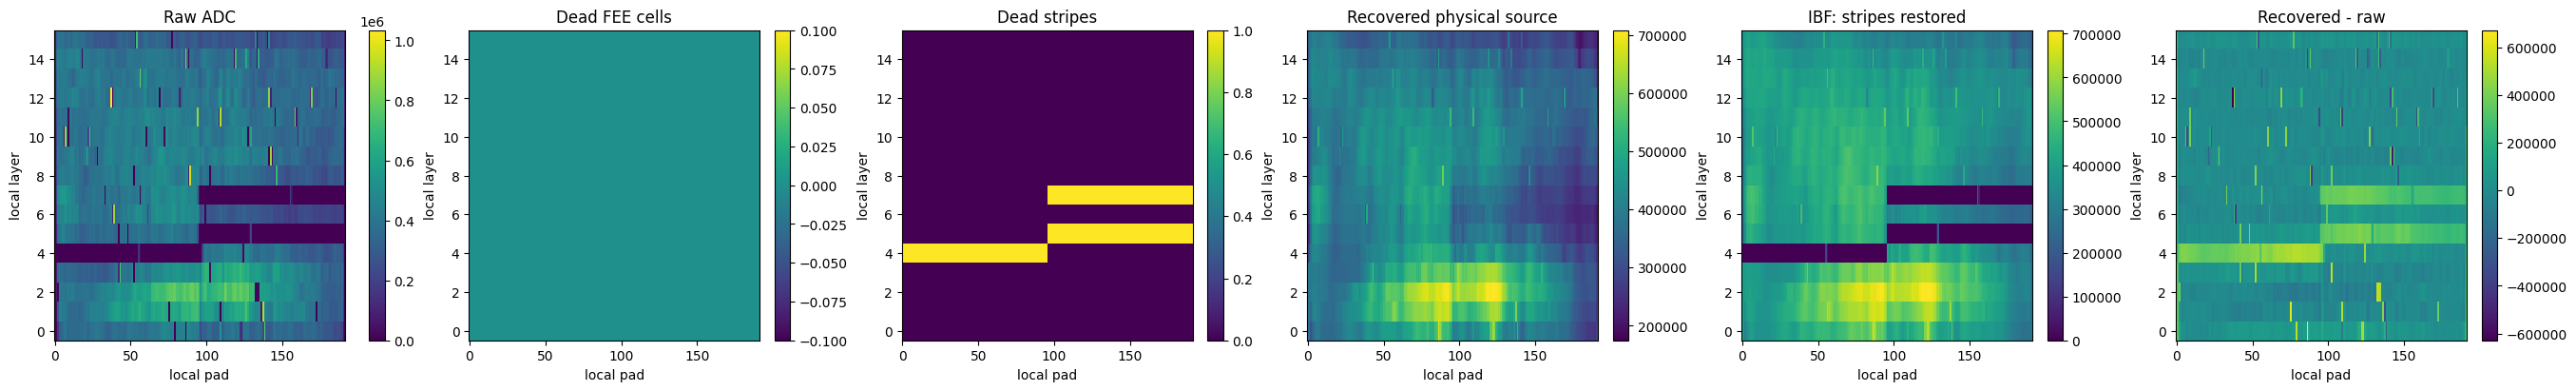

Dead FEE: []
Stripes: [('half-left', 4, 0.9791666666666666), ('half-right', 5, 0.9895833333333334), ('half-right', 7, 0.9895833333333334)]
Blocks: [(0, 4, 0, 3, 8), (0, 5, 190, 192, 6)]


In [8]:
QA_SIDE=0
QA_MODULE=2
QA_SECTOR=0
key=(QA_SIDE,QA_MODULE,QA_SECTOR)

if key in raw_maps:
    raw=raw_maps[key]["adc"]
    model=model_clean_maps[key]
    ibf=ibf_native_maps[key]
    m=auto_masks[key]

    fig,ax=plt.subplots(1,6,figsize=(27,4),constrained_layout=True)
    panels=[(raw,"Raw ADC"),(m["fee"],"Dead FEE cells"),(m["stripe"],"Dead stripes"),
            (model,"Recovered physical source"),(ibf,"IBF: stripes restored"),(model-raw,"Recovered - raw")]
    for a,(z,title) in zip(ax,panels):
        im=a.imshow(z,aspect="auto",origin="lower",interpolation="nearest")
        a.set_title(title); a.set_xlabel("local pad"); a.set_ylabel("local layer")
        plt.colorbar(im,ax=a)
    plt.show()

    print("Dead FEE:",m["fee_regions"])
    print("Stripes:",m["stripe_details"])
    print("Blocks:",m["block_details"])


## 5. Build measured global `(r,phi)` ADC and IBF-density maps

For each pad,

\[
A_{\rm pad}(r)\simeq r\,\Delta\phi\,\Delta r,
\qquad
\rho_{\rm IBF}\propto ADC/A_{\rm pad}.
\]

Bins with no physical pad coverage remain `NaN`, preserving sector gaps.


In [9]:
phi_edges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
phi_centers=0.5*(phi_edges[:-1]+phi_edges[1:])
all_r=np.concatenate([module_layer_radii_cm(m) for m in range(N_MODULES)])
all_r=np.sort(all_r)

def phi_bin_index(phi):
    idx=np.floor((phi-PHI_MIN)/(PHI_MAX-PHI_MIN)*GLOBAL_PHI_BINS).astype(int)
    return np.clip(idx,0,GLOBAL_PHI_BINS-1)

def build_global_measured_maps(side,native_maps):
    adc_sum=np.zeros((len(all_r),GLOBAL_PHI_BINS))
    rho_sum=np.zeros_like(adc_sum)
    counts=np.zeros_like(adc_sum)
    repaired_counts=np.zeros_like(adc_sum)

    rlookup={(m,il):int(np.argmin(np.abs(all_r-r)))
             for m in range(N_MODULES) for il,r in enumerate(module_layer_radii_cm(m))}

    for module in range(N_MODULES):
        for sector in range(N_SECTORS):
            key=(side,module,sector)
            if key not in native_maps: continue
            a=native_maps[key]
            repaired=repair_masks[key]

            for il in range(LAYERS_PER_MODULE):
                ir=rlookup[(module,il)]
                bins=phi_bin_index(sector_phi_centers(module,sector,il,side))
                area=pad_area_cm2(module,il,side)

                for ip,val in enumerate(a[il]):
                    if not np.isfinite(val): continue
                    ib=bins[ip]
                    adc_sum[ir,ib]+=val
                    rho_sum[ir,ib]+=val/area
                    counts[ir,ib]+=1
                    repaired_counts[ir,ib]+=float(repaired[il,ip])

    adc=np.full_like(adc_sum,np.nan); rho=np.full_like(rho_sum,np.nan)
    repaired_fraction=np.full_like(rho_sum,np.nan)
    good=counts>0
    adc[good]=adc_sum[good]/counts[good]
    rho[good]=rho_sum[good]/counts[good]
    repaired_fraction[good]=repaired_counts[good]/counts[good]
    return adc,rho,counts,repaired_fraction

adc_measured={}
ibf_measured={}
ibf_measured_clean={}
coverage_measured={}
coverage_clean={}
repair_fraction_measured={}

for side in range(N_SIDES):
    adc_measured[side],ibf_measured[side],coverage_measured[side],repair_fraction_measured[side] = \
        build_global_measured_maps(side,ibf_native_maps)
    _,ibf_measured_clean[side],coverage_clean[side],_ = \
        build_global_measured_maps(side,model_clean_maps)

print("Measured r-phi maps built")

# Explicit coverage diagnostic around +/-pi.
for side in range(N_SIDES):
    ncover=np.sum(coverage_measured[side]>0,axis=0)
    print(f"side {side}: covered phi bins = {np.count_nonzero(ncover)}/{GLOBAL_PHI_BINS}, "
          f"edge coverage (-pi,+pi) = {ncover[0]}, {ncover[-1]}")


Measured r-phi maps built
side 0: covered phi bins = 708/720, edge coverage (-pi,+pi) = 48, 48
side 1: covered phi bins = 708/720, edge coverage (-pi,+pi) = 48, 48


## 6. Inner extrapolation: robust reference density and controlled phi damping

The previous empty extrapolation had a simple cause:

```python
N_R1_AMPLITUDE_LAYERS = 8
MIN_POINTS_FOR_PHI_AMPLITUDE = 10
```

so **no phi bin could ever satisfy the minimum of 10 points**.

This version uses

```python
N_R1_AMPLITUDE_LAYERS = 16
MIN_POINTS_FOR_PHI_AMPLITUDE = 10
```

so the reference density is estimated from the full measured R1 module, after
transporting every layer back to the same reference radius using alpha(phi).

The model is

\[
\rho(r,\phi)
=
\rho_{\rm ref}(\phi)
\left(\frac{R_{\rm ref}}{r}\right)^{\alpha(\phi)}.
\]

For a fine phi bin, `rho_ref(phi)` is accepted only if at least 10 R1 layers
contribute. Because exact pad-center phi changes slightly with radius, a few fine
phi bins can still be missing even though the sector itself is healthy. Those holes
are filled **only by interpolation inside the same physical sector** before the
sector-local smoothing is applied. Physical sector gaps remain gaps.

Below the first measured R1 radius we optionally damp only the relative phi
modulation while keeping the radial power-law behavior.


Reference radius for parameterization: R_REF = 31.781 cm
Extrapolation boundary: r < 31.781 cm only
IBF side 0: constant alpha=1.420; final alpha=lowharmonic; final rho_ref=sector_smooth; phi damping=keep50


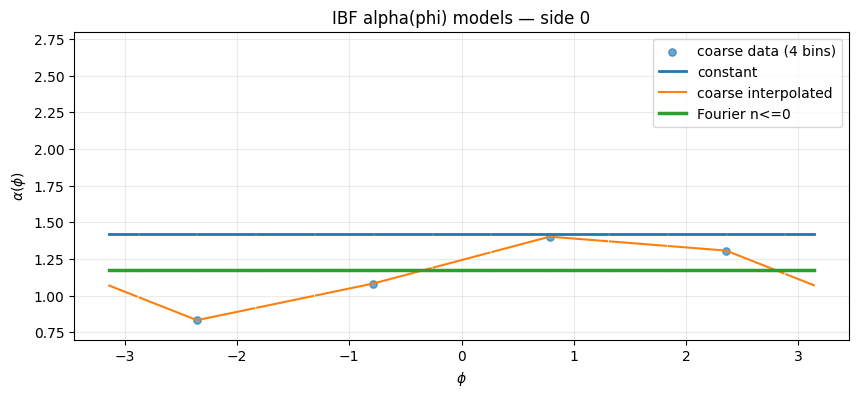

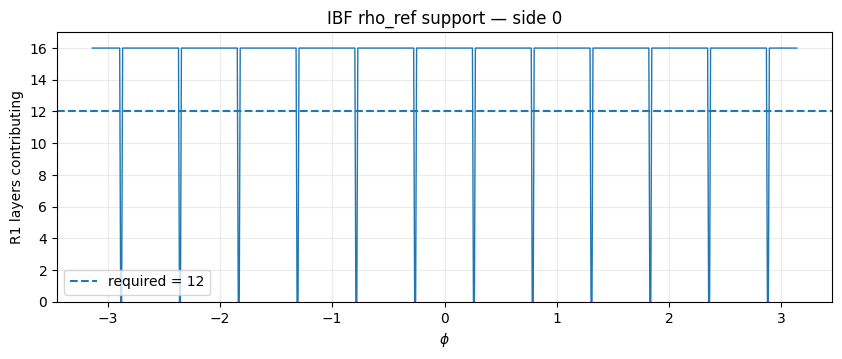

IBF side 0: raw rho_ref valid fine phi bins = 696/720


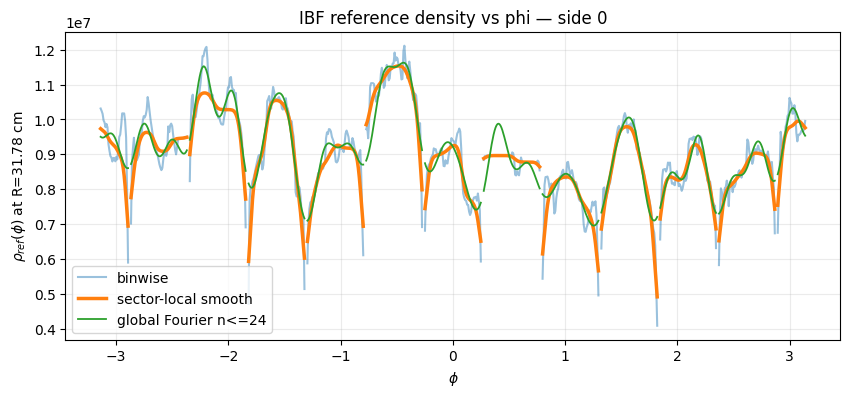

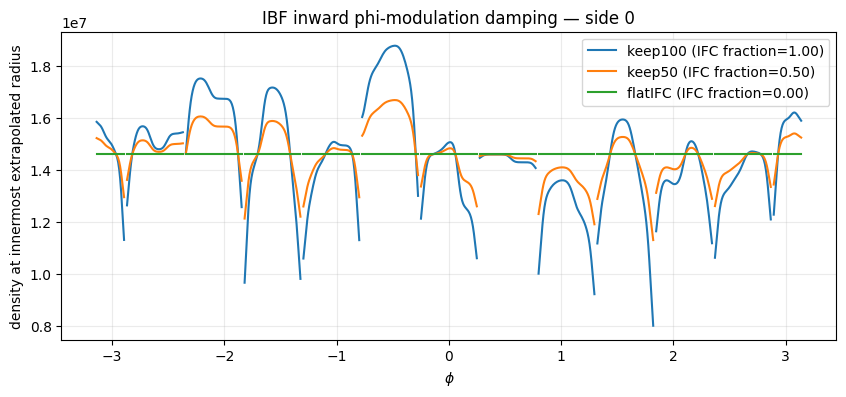

IBF side 1: constant alpha=1.756; final alpha=lowharmonic; final rho_ref=sector_smooth; phi damping=keep50


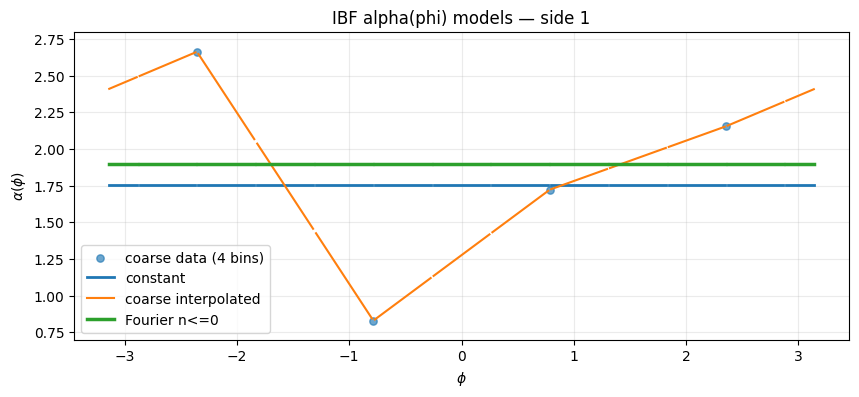

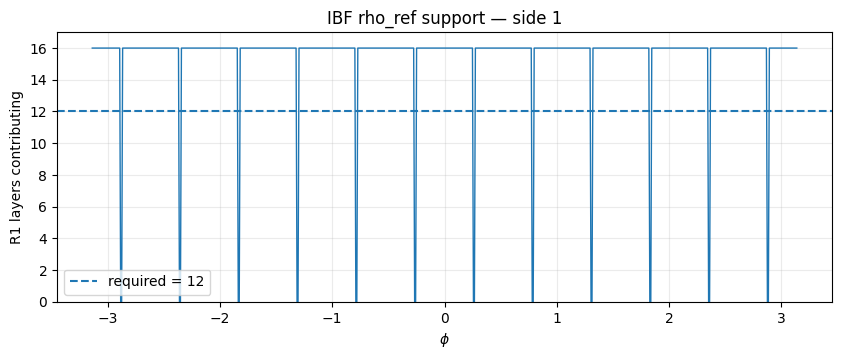

IBF side 1: raw rho_ref valid fine phi bins = 696/720


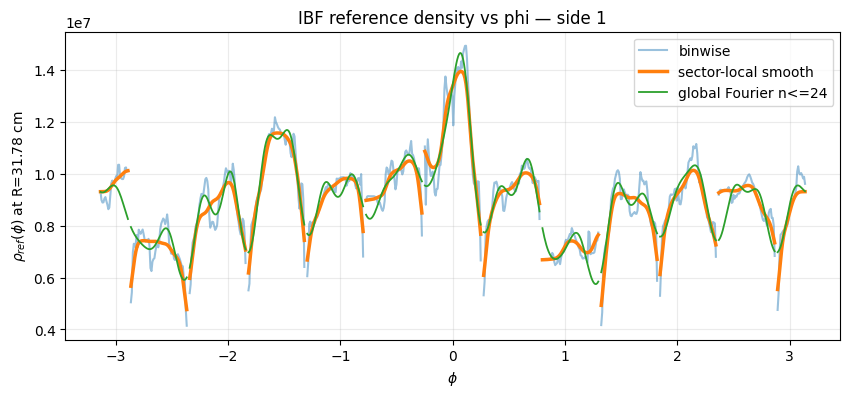

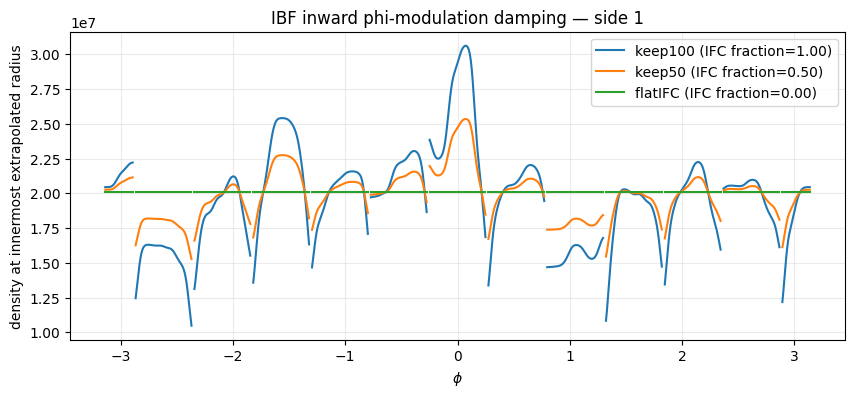

Added 24 inner radial bins down to 21.0 cm


In [10]:
def robust_r1_alpha_fit(rho, coverage, repair_fraction, rvals):
    """One robust side-wide alpha used as the constant-alpha reference."""
    nfit=min(N_R1_FIT_LAYERS,16,len(rvals))
    fit_r=[]; fit_y=[]; fit_sigma=[]; fit_weight=[]

    for ir in range(nfit):
        y=rho[ir]
        good=(coverage[ir]>0) & np.isfinite(y) & (y>0)
        if np.count_nonzero(good)<MIN_PHI_BINS_PER_R_LAYER:
            continue

        vals=y[good]
        logv=np.log(vals)
        med=np.median(vals)
        madlog=1.4826*np.median(np.abs(logv-np.median(logv)))
        if not np.isfinite(madlog) or madlog<0.02:
            madlog=0.02

        rep=repair_fraction[ir,good]
        healthy_fraction=np.mean(1.0-np.nan_to_num(rep,nan=1.0))
        if healthy_fraction<MIN_HEALTHY_FRACTION_FOR_ALPHA:
            continue

        n=np.count_nonzero(good)
        fit_r.append(rvals[ir])
        fit_y.append(med)
        fit_sigma.append(max(madlog/np.sqrt(max(n,1)),0.015))
        fit_weight.append(np.sqrt(healthy_fraction))

    fit_r=np.asarray(fit_r,float)
    fit_y=np.asarray(fit_y,float)
    fit_sigma=np.asarray(fit_sigma,float)
    fit_weight=np.asarray(fit_weight,float)

    if len(fit_r)<3:
        alpha=ALPHA_INITIAL
        logA=np.nanmedian(np.log(fit_y)+alpha*np.log(fit_r)) if len(fit_r) else 0.0
        return alpha,np.exp(logA),(fit_r,fit_y,fit_sigma,fit_weight),None

    logy=np.log(fit_y)

    def residual(par):
        logA,alpha=par
        return fit_weight*(logA-alpha*np.log(fit_r)-logy)/fit_sigma

    x0=[np.median(logy+ALPHA_INITIAL*np.log(fit_r)),ALPHA_INITIAL]
    result=least_squares(
        residual,x0,
        bounds=([-np.inf,ALPHA_BOUNDS[0]],[np.inf,ALPHA_BOUNDS[1]]),
        loss=ALPHA_LOSS,f_scale=ALPHA_F_SCALE
    )
    logA,alpha=result.x
    return float(alpha),float(np.exp(logA)),(fit_r,fit_y,fit_sigma,fit_weight),result


def circular_phi_distance(phi,center):
    return np.abs((phi-center+np.pi)%(2*np.pi)-np.pi)


def fit_alpha_in_coarse_phi_bins(rho,coverage,repair_fraction,rvals,alpha_seed):
    """
    Extract alpha on a deliberately coarse phi grid.

    For each coarse phi bin:
      1) for every R1 layer, take a robust weighted median across all fine phi bins;
      2) fit log(rho) vs log(r) across R1;
      3) constrain alpha to ALPHA_BOUNDS.

    This is much more stable than fitting alpha independently in 720 fine bins.
    """
    nfit=min(N_R1_FIT_LAYERS,16,len(rvals))
    edges=np.linspace(PHI_MIN,PHI_MAX,ALPHA_N_PHI_BINS+1)
    centers=0.5*(edges[:-1]+edges[1:])

    alpha=np.full(ALPHA_N_PHI_BINS,np.nan)
    quality=np.zeros(ALPHA_N_PHI_BINS)
    npoints=np.zeros(ALPHA_N_PHI_BINS,dtype=int)

    for ib in range(ALPHA_N_PHI_BINS):
        if ib==ALPHA_N_PHI_BINS-1:
            pmask=(phi_centers>=edges[ib]) & (phi_centers<=edges[ib+1])
        else:
            pmask=(phi_centers>=edges[ib]) & (phi_centers<edges[ib+1])

        rr=[]; yy=[]; ww=[]

        for ir in range(nfit):
            good=(pmask &
                  (coverage[ir]>0) &
                  np.isfinite(rho[ir]) &
                  (rho[ir]>0))
            if np.count_nonzero(good)<2:
                continue

            vals=rho[ir,good]
            rep=repair_fraction[ir,good]
            weights=np.clip(1.0-np.nan_to_num(rep,nan=1.0),0.05,1.0)

            med=weighted_median(vals,weights)
            if not np.isfinite(med) or med<=0:
                continue

            rr.append(rvals[ir])
            yy.append(med)
            ww.append(np.sqrt(np.sum(weights)))

        rr=np.asarray(rr,float)
        yy=np.asarray(yy,float)
        ww=np.asarray(ww,float)
        npoints[ib]=len(rr)

        if len(rr)<MIN_R1_POINTS_PER_ALPHA_BIN:
            continue

        logy=np.log(yy)
        ww=ww/np.nanmedian(ww)

        def res(par):
            log_rhoref,a=par
            model=log_rhoref-a*np.log(rr/R_REF)
            return ww*(model-logy)

        x0=[np.median(logy+alpha_seed*np.log(rr/R_REF)),alpha_seed]

        try:
            fit=least_squares(
                res,x0,
                bounds=([-np.inf,ALPHA_BOUNDS[0]],[np.inf,ALPHA_BOUNDS[1]]),
                loss="soft_l1",
                f_scale=max(robust_scale(logy),0.04)
            )
            alpha[ib]=fit.x[1]
            quality[ib]=np.sum(ww)
        except Exception:
            pass

    return centers,alpha,quality,npoints


def periodic_interp_to_fine(coarse_phi,coarse_values):
    good=np.isfinite(coarse_values)
    if np.count_nonzero(good)<2:
        return np.full(GLOBAL_PHI_BINS,np.nan)

    x=coarse_phi[good]
    y=coarse_values[good]
    order=np.argsort(x)
    x=x[order]; y=y[order]

    xext=np.r_[x[-1]-2*np.pi,x,x[0]+2*np.pi]
    yext=np.r_[y[-1],y,y[0]]
    return np.interp(phi_centers,xext,yext)


def robust_fourier_fit_coarse(coarse_phi,values,quality,max_harmonic):
    good=np.isfinite(values) & np.isfinite(quality) & (quality>0)
    phi=coarse_phi[good]
    y=values[good]
    q=quality[good]

    cols=[np.ones_like(phi)]
    names=["const"]
    for n in range(1,max_harmonic+1):
        cols += [np.cos(n*phi),np.sin(n*phi)]
        names += [f"cos{n}",f"sin{n}"]

    X=np.column_stack(cols)
    w=np.sqrt(q/np.nanmedian(q))
    coef0,*_=np.linalg.lstsq(X*w[:,None],y*w,rcond=None)

    scale=max(robust_scale(y),0.03)
    def res(c):
        return w*(X@c-y)/scale

    fit=least_squares(res,coef0,loss="soft_l1",f_scale=1.0)
    coef=fit.x

    cols_all=[np.ones_like(phi_centers)]
    for n in range(1,max_harmonic+1):
        cols_all += [np.cos(n*phi_centers),np.sin(n*phi_centers)]

    pred=np.column_stack(cols_all)@coef
    pred=np.clip(pred,ALPHA_BOUNDS[0],ALPHA_BOUNDS[1])
    return pred,coef,names,fit


def build_phi_sector_lookup(side):
    votes=np.zeros((N_SECTORS,GLOBAL_PHI_BINS),dtype=int)
    module=0

    for sector in range(N_SECTORS):
        for il in range(min(4,LAYERS_PER_MODULE)):
            ph=sector_phi_centers(module,sector,il,side)
            bins=phi_bin_index(ph)
            for b in bins:
                votes[sector,b]+=1

    sid=np.full(GLOBAL_PHI_BINS,-1,dtype=int)
    has=np.max(votes,axis=0)>0
    sid[has]=np.argmax(votes[:,has],axis=0)
    return sid


def cyclic_order_indices(indices,n_total):
    idx=np.sort(np.asarray(indices,dtype=int))
    if len(idx)<=1:
        return idx
    gaps=np.diff(np.r_[idx,idx[0]+n_total])
    cut=np.argmax(gaps)
    return np.r_[idx[cut+1:],idx[:cut+1]]


def sector_smooth_rhoref(rhoref,sector_lookup):
    """
    Smooth rho_ref(phi) inside each physical sector only.

    Important:
      * physical sector gaps remain NaN;
      * missing fine phi bins inside a sector can be interpolated from valid
        neighbors in that same sector before smoothing.
    """
    out=np.full_like(rhoref,np.nan,dtype=float)

    win=int(RHOREF_SECTOR_MEDIAN_WINDOW)
    if win%2==0:
        win+=1

    for sec in range(N_SECTORS):
        sector_idx=np.where(sector_lookup==sec)[0]
        if len(sector_idx)==0:
            continue

        order=cyclic_order_indices(sector_idx,GLOBAL_PHI_BINS)
        vals=rhoref[order].astype(float)
        valid=np.isfinite(vals) & (vals>0)

        if np.count_nonzero(valid)==0:
            continue

        # Fill holes only inside this sector. This is needed because exact pad
        # centers do not occupy exactly the same fine phi bins in all R1 layers.
        if RHOREF_FILL_MISSING_WITHIN_SECTOR and np.count_nonzero(valid)>=2:
            x=np.arange(len(vals),dtype=float)
            vals_filled=vals.copy()
            vals_filled[~valid]=np.interp(
                x[~valid],x[valid],vals[valid]
            )
        else:
            vals_filled=vals.copy()

        finite=np.isfinite(vals_filled) & (vals_filled>0)
        if np.count_nonzero(finite)<3:
            out[order[finite]]=vals_filled[finite]
            continue

        # Interpolation above should normally make the sector fully finite.
        # If not, smooth only the contiguous finite portion.
        lv=np.log(vals_filled)
        use_win=min(win,max(3,(len(lv)//2)*2-1))
        med=ndimage.median_filter(lv,size=use_win,mode="nearest")
        smooth=ndimage.gaussian_filter1d(
            med,sigma=RHOREF_SECTOR_GAUSS_SIGMA,mode="nearest"
        )
        out[order]=np.exp(smooth)

    return out


def extract_rhoref(rho,coverage,repair_fraction,rvals,alpha_phi):
    """
    rho_ref(phi) = weighted median[
        rho(r,phi) * (r/R_REF)^alpha(phi)
    ]

    rho_ref therefore always has density units.
    """
    n_amp=min(N_R1_AMPLITUDE_LAYERS,16,len(rvals))

    if MIN_POINTS_FOR_PHI_AMPLITUDE > n_amp:
        raise ValueError(
            "MIN_POINTS_FOR_PHI_AMPLITUDE cannot exceed the number of R1 layers "
            f"used for rho_ref: min points={MIN_POINTS_FOR_PHI_AMPLITUDE}, "
            f"layers used={n_amp}"
        )
    physical_phi=np.sum(coverage[:16]>0,axis=0)>=MIN_R1_COVERAGE_LAYERS

    rhoref=np.full(rho.shape[1],np.nan)
    quality=np.zeros(rho.shape[1])
    n_used=np.zeros(rho.shape[1],dtype=int)

    for ip in range(rho.shape[1]):
        if not physical_phi[ip] or not np.isfinite(alpha_phi[ip]):
            continue

        vals=[]; weights=[]
        for ir in range(n_amp):
            y=rho[ir,ip]
            if not np.isfinite(y) or y<=0 or coverage[ir,ip]<=0:
                continue

            rep=repair_fraction[ir,ip]
            healthy=max(0.05,1.0-(rep if np.isfinite(rep) else 1.0))

            vals.append(y*(rvals[ir]/R_REF)**alpha_phi[ip])
            weights.append(healthy)

        n_used[ip]=len(vals)

        if len(vals)>=MIN_POINTS_FOR_PHI_AMPLITUDE:
            rhoref[ip]=weighted_median(vals,weights)
            quality[ip]=np.sum(weights)

    return rhoref,quality,physical_phi,n_used


def highharmonic_rhoref(rhoref,quality):
    good=np.isfinite(rhoref) & (rhoref>0) & np.isfinite(quality) & (quality>0)
    phi=phi_centers[good]
    y=np.log(rhoref[good])
    q=quality[good]

    cols=[np.ones_like(phi)]
    for n in range(1,RHOREF_HIGH_HARMONIC+1):
        cols += [np.cos(n*phi),np.sin(n*phi)]

    X=np.column_stack(cols)
    w=np.sqrt(q/np.nanmedian(q))
    coef0,*_=np.linalg.lstsq(X*w[:,None],y*w,rcond=None)

    scale=max(robust_scale(y),0.05)
    def res(c):
        return w*(X@c-y)/scale

    fit=least_squares(res,coef0,loss="soft_l1",f_scale=1.0)
    coef=fit.x

    cols_all=[np.ones_like(phi_centers)]
    for n in range(1,RHOREF_HIGH_HARMONIC+1):
        cols_all += [np.cos(n*phi_centers),np.sin(n*phi_centers)]

    pred=np.exp(np.column_stack(cols_all)@coef)
    pred[~np.isfinite(rhoref)]=np.nan
    return pred,coef,fit


def modulation_scale(r, r_boundary, f_ifc):
    """
    S(r_boundary)=1 and S(IFC_RADIUS_CM)=f_ifc.
    """
    if PHI_MODULATION_DAMPING == "linear":
        if r_boundary <= IFC_RADIUS_CM:
            return 1.0
        t=(r-IFC_RADIUS_CM)/(r_boundary-IFC_RADIUS_CM)
        t=np.clip(t,0.0,1.0)
        return f_ifc + (1.0-f_ifc)*t
    raise ValueError(f"Unknown PHI_MODULATION_DAMPING={PHI_MODULATION_DAMPING}")


def build_reference_powerlaw_map(rho,rvals,alpha_phi,rhoref,
                                 phi_modulation_ifc_fraction=1.0):
    """
    Extrapolate only below first measured R1.

    rho_ref(phi) is decomposed into a robust mean and relative phi modulation.
    Only the modulation is damped inward; the mean radial profile remains.
    """
    r_boundary=rvals[0]
    extra_r=np.linspace(IFC_RADIUS_CM,r_boundary,N_INNER_EXTRAP_BINS,endpoint=False)

    out_r=np.concatenate([extra_r,rvals])
    out=np.full((len(out_r),rho.shape[1]),np.nan)

    # IMPORTANT: measured region is copied exactly, untouched.
    out[len(extra_r):]=rho

    good=np.isfinite(rhoref) & (rhoref>0) & np.isfinite(alpha_phi)
    if not np.any(good):
        return out_r,out,len(extra_r)

    # Robust phi-average reference density.
    ref_mean=np.nanmedian(rhoref[good])
    delta=np.full_like(rhoref,np.nan,dtype=float)
    delta[good]=rhoref[good]/ref_mean - 1.0

    for i,r in enumerate(extra_r):
        S=modulation_scale(r,r_boundary,phi_modulation_ifc_fraction)
        local_ref=np.full_like(rhoref,np.nan,dtype=float)
        local_ref[good]=ref_mean*(1.0 + S*delta[good])

        # Guard against pathological negative values if delta is very large.
        local_ref[good]=np.clip(local_ref[good],0.0,None)

        out[i,good]=local_ref[good]*(R_REF/r)**alpha_phi[good]

    return out_r,out,len(extra_r)


def construct_extrapolation_family(rho,coverage,repair_fraction,rvals,side,label):
    alpha0,A0,fitpts,result=robust_r1_alpha_fit(
        rho,coverage,repair_fraction,rvals
    )

    coarse_phi,alpha_coarse_raw,alpha_quality,alpha_npoints = fit_alpha_in_coarse_phi_bins(
        rho,coverage,repair_fraction,rvals,alpha0
    )

    alpha_coarse_fine=periodic_interp_to_fine(coarse_phi,alpha_coarse_raw)
    alpha_low,coef_low,names_low,_=robust_fourier_fit_coarse(
        coarse_phi,alpha_coarse_raw,alpha_quality,ALPHA_LOW_HARMONIC
    )

    physical=np.any(coverage[:16]>0,axis=0)
    alpha_constant=np.full(rho.shape[1],np.nan)
    alpha_constant[physical]=alpha0
    alpha_coarse_fine[~physical]=np.nan
    alpha_low[~physical]=np.nan

    alpha_models={
        "constant":alpha_constant,
        "coarse":alpha_coarse_fine,
        "lowharmonic":alpha_low,
    }
    final_alpha=alpha_models[ALPHA_PHI_FINAL]

    rhoref_bin,qref,_,rhoref_n_used=extract_rhoref(
        rho,coverage,repair_fraction,rvals,final_alpha
    )

    sector_lookup=build_phi_sector_lookup(side)
    rhoref_sector=sector_smooth_rhoref(rhoref_bin,sector_lookup)
    rhoref_high,coef_high,_=highharmonic_rhoref(rhoref_bin,qref)

    rhoref_models={
        "binwise":rhoref_bin,
        "sector_smooth":rhoref_sector,
        "highharmonic":rhoref_high,
    }
    final_rhoref=rhoref_models[RHOREF_PHI_FINAL]

    # Compare alpha choices while using the same rho_ref prescription.
    alpha_maps={}
    for mode,aphi in alpha_models.items():
        ref_bin,qtmp,_,_=extract_rhoref(
            rho,coverage,repair_fraction,rvals,aphi
        )
        if RHOREF_PHI_FINAL=="binwise":
            ref_use=ref_bin
        elif RHOREF_PHI_FINAL=="sector_smooth":
            ref_use=sector_smooth_rhoref(ref_bin,sector_lookup)
        else:
            ref_use=highharmonic_rhoref(ref_bin,qtmp)[0]

        rfull,tmp,nextra=build_reference_powerlaw_map(
            rho,rvals,aphi,ref_use
        )
        alpha_maps[mode]=tmp

    # Compare multiplicity models while using preferred alpha(phi).
    # For this comparison, preserve 100% of phi modulation so only the A/rho_ref
    # prescription changes.
    ref_maps={}
    for mode,refphi in rhoref_models.items():
        rfull,tmp,nextra=build_reference_powerlaw_map(
            rho,rvals,final_alpha,refphi,
            phi_modulation_ifc_fraction=1.0
        )
        ref_maps[mode]=tmp

    # NEW: compare how much of the measured phi modulation survives inward.
    damping_maps={}
    damping_labels={}
    for frac in PHI_MODULATION_IFC_FRACTIONS:
        if abs(frac-1.0)<1e-9:
            tag="keep100"
        elif abs(frac-0.5)<1e-9:
            tag="keep50"
        elif abs(frac)<1e-9:
            tag="flatIFC"
        else:
            tag=f"keep{int(round(100*frac))}"

        rfull,tmp,nextra=build_reference_powerlaw_map(
            rho,rvals,final_alpha,final_rhoref,
            phi_modulation_ifc_fraction=float(frac)
        )
        damping_maps[tag]=tmp
        damping_labels[tag]=float(frac)

    # Select requested final damping fraction.
    final_tag=None
    for tag,frac in damping_labels.items():
        if abs(frac-PHI_MODULATION_IFC_FINAL)<1e-9:
            final_tag=tag
            break

    if final_tag is None:
        # Support arbitrary fraction not explicitly in the QA list.
        final_tag=f"keep{int(round(100*PHI_MODULATION_IFC_FINAL))}"
        rfull,tmp,nextra=build_reference_powerlaw_map(
            rho,rvals,final_alpha,final_rhoref,
            phi_modulation_ifc_fraction=float(PHI_MODULATION_IFC_FINAL)
        )
        damping_maps[final_tag]=tmp
        damping_labels[final_tag]=float(PHI_MODULATION_IFC_FINAL)

    return {
        "alpha0":alpha0,
        "alpha_fitpts":fitpts,
        "alpha_coarse_phi":coarse_phi,
        "alpha_coarse_raw":alpha_coarse_raw,
        "alpha_quality":alpha_quality,
        "alpha_npoints":alpha_npoints,
        "alpha_models":alpha_models,
        "alpha_maps":alpha_maps,
        "rhoref_models":rhoref_models,
        "rhoref_n_used":rhoref_n_used,
        "rhoref_maps":ref_maps,
        "damping_maps":damping_maps,
        "damping_labels":damping_labels,
        "final_damping_tag":final_tag,
        "final_alpha":final_alpha,
        "final_rhoref":final_rhoref,
        "final_map":damping_maps[final_tag],
        "sector_lookup":sector_lookup,
        "r_full":rfull,
        "n_extrap":nextra,
        "alpha_coeff_low":(coef_low,names_low),
        "rhoref_coeff_high":coef_high,
    }


R_REF = all_r[0] if R_REF_CM is None else float(R_REF_CM)

# R_REF is only the normalization radius. It does not define the extrapolation
# boundary. The extrapolation boundary is ALWAYS the first measured R1 radius.
if not ALLOW_EXTERNAL_R_REF:
    r1_max = all_r[min(15, len(all_r)-1)]
    if R_REF < all_r[0]-2.0 or R_REF > r1_max+2.0:
        raise ValueError(
            f"R_REF_CM={R_REF:.3f} cm is far outside measured R1. "
            f"Use R_REF_CM=None (recommended -> {all_r[0]:.3f} cm), "
            "or set ALLOW_EXTERNAL_R_REF=True intentionally."
        )

print(f"Reference radius for parameterization: R_REF = {R_REF:.3f} cm")
print(f"Extrapolation boundary: r < {all_r[0]:.3f} cm only")

ibf_family={}
ibf_map={}
ibf_alpha={}
ibf_alpha_fit_points={}
ibf_alpha_models={}
ibf_rhoref_variants={}
ibf_alpha_map_variants={}
ibf_rhoref_map_variants={}
ibf_damping_map_variants={}

for side in range(N_SIDES):
    fam=construct_extrapolation_family(
        ibf_measured_clean[side],coverage_clean[side],
        repair_fraction_measured[side],all_r,side,"IBF"
    )

    ibf_family[side]=fam
    ibf_map[side]=fam["final_map"].copy()
    # The extrapolated region comes from the fully recovered/smoothed physical
    # source. Only the measured region gets the actual dead stripes restored.
    ibf_map[side][fam["n_extrap"]:,:]=ibf_measured[side]
    ibf_alpha[side]=fam["alpha0"]
    ibf_alpha_fit_points[side]=fam["alpha_fitpts"]
    ibf_alpha_models[side]=fam["alpha_models"]
    ibf_rhoref_variants[side]=fam["rhoref_models"]
    ibf_alpha_map_variants[side]=fam["alpha_maps"]
    ibf_rhoref_map_variants[side]=fam["rhoref_maps"]
    ibf_damping_map_variants[side]=fam["damping_maps"]
    r_full=fam["r_full"]
    n_extrap=fam["n_extrap"]

    print(
        f"IBF side {side}: constant alpha={fam['alpha0']:.3f}; "
        f"final alpha={ALPHA_PHI_FINAL}; final rho_ref={RHOREF_PHI_FINAL}; "
        f"phi damping={fam['final_damping_tag']}"
    )

    # alpha(phi): show only meaningful coarse measurements plus models
    plt.figure(figsize=(10,4))
    good=np.isfinite(fam["alpha_coarse_raw"])
    plt.scatter(
        fam["alpha_coarse_phi"][good],
        fam["alpha_coarse_raw"][good],
        s=28,alpha=0.65,label=f"coarse data ({ALPHA_N_PHI_BINS} bins)"
    )
    plt.plot(phi_centers,fam["alpha_models"]["constant"],
             label="constant",lw=2)
    plt.plot(phi_centers,fam["alpha_models"]["coarse"],
             label="coarse interpolated",lw=1.5)
    plt.plot(phi_centers,fam["alpha_models"]["lowharmonic"],
             label=f"Fourier n<={ALPHA_LOW_HARMONIC}",lw=2.5)

    plt.ylim(ALPHA_BOUNDS[0]-0.1,ALPHA_BOUNDS[1]+0.1)
    plt.xlabel(r"$\phi$")
    plt.ylabel(r"$\alpha(\phi)$")
    plt.title(f"IBF alpha(phi) models — side {side}")
    plt.grid(alpha=0.25); plt.legend()
    plt.savefig(QA_PLOT_DIR/f"ibf_alpha_phi_models_side{side}.png",
                dpi=160,bbox_inches="tight")
    plt.show()

    # QA: how many R1 layers contributed to each fine phi bin?
    plt.figure(figsize=(10,3.5))
    plt.plot(phi_centers,fam["rhoref_n_used"],lw=1)
    plt.axhline(MIN_POINTS_FOR_PHI_AMPLITUDE,ls="--",
                label=f"required = {MIN_POINTS_FOR_PHI_AMPLITUDE}")
    plt.xlabel(r"$\phi$")
    plt.ylabel("R1 layers contributing")
    plt.title(f"IBF rho_ref support — side {side}")
    plt.ylim(0,N_R1_AMPLITUDE_LAYERS+1)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.savefig(QA_PLOT_DIR/f"ibf_rhoref_npoints_side{side}.png",
                dpi=160,bbox_inches="tight")
    plt.show()

    nvalid=np.count_nonzero(np.isfinite(fam["rhoref_models"]["binwise"]))
    print(f"IBF side {side}: raw rho_ref valid fine phi bins = "
          f"{nvalid}/{GLOBAL_PHI_BINS}")

    # rho_ref(phi), now directly interpretable in density units
    plt.figure(figsize=(10,4))
    plt.plot(phi_centers,fam["rhoref_models"]["binwise"],
             label="binwise",alpha=0.45)
    plt.plot(phi_centers,fam["rhoref_models"]["sector_smooth"],
             label="sector-local smooth",lw=2.5)
    plt.plot(phi_centers,fam["rhoref_models"]["highharmonic"],
             label=f"global Fourier n<={RHOREF_HIGH_HARMONIC}",lw=1.3)
    plt.xlabel(r"$\phi$")
    plt.ylabel(fr"$\rho_{{ref}}(\phi)$ at R={R_REF:.2f} cm")
    plt.title(f"IBF reference density vs phi — side {side}")
    plt.grid(alpha=0.25); plt.legend()
    plt.savefig(QA_PLOT_DIR/f"ibf_rhoref_models_side{side}.png",
                dpi=160,bbox_inches="tight")
    plt.show()


    # Show phi profiles in the innermost extrapolated bin for damping choices.
    plt.figure(figsize=(10,4))
    for tag,m in fam["damping_maps"].items():
        plt.plot(phi_centers,m[0],label=f"{tag} (IFC fraction={fam['damping_labels'][tag]:.2f})")
    plt.xlabel(r"$\phi$")
    plt.ylabel("density at innermost extrapolated radius")
    plt.title(f"IBF inward phi-modulation damping — side {side}")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.savefig(QA_PLOT_DIR/f"ibf_phi_damping_profiles_side{side}.png",
                dpi=160,bbox_inches="tight")
    plt.show()

print(f"Added {n_extrap} inner radial bins down to {IFC_RADIUS_CM} cm")


## 7. Final IBF maps and r / phi profiles

In [11]:
def fit_radial_powerlaw(rvals, yvals, rmax):
    """
    Fit extrapolated region with

        y(r) = A * (R_REF / r)^alpha
    """

    mask = (
        np.isfinite(rvals)
        & np.isfinite(yvals)
        & (yvals > 0)
        & (rvals >= IFC_RADIUS_CM)
        & (rvals < rmax)
    )

    rfit = rvals[mask]
    yfit = yvals[mask]

    if len(rfit) < 3:
        return None

    def residual(par):
        logA, alpha = par
        model = logA + alpha * np.log(R_REF / rfit)
        return model - np.log(yfit)

    x0 = [
        np.median(np.log(yfit)),
        ALPHA_INITIAL
    ]

    result = least_squares(
        residual,
        x0,
        bounds=(
            [-np.inf, ALPHA_BOUNDS[0]],
            [ np.inf, ALPHA_BOUNDS[1]]
        ),
        loss="soft_l1",
        f_scale=1.0
    )

    logA, alpha = result.x
    A = np.exp(logA)

    return A, alpha

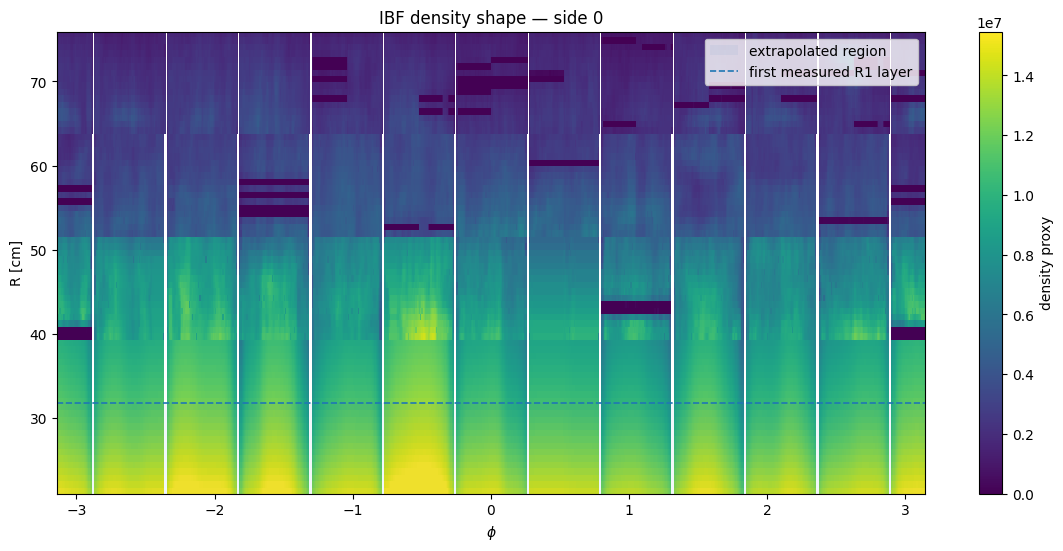

/tmp/ipykernel_64145/2693005249.py:26: RuntimeWarning: All-NaN slice encountered
  ibf_profile_phi[side]=np.nanmedian(ibf_map[side],axis=0)


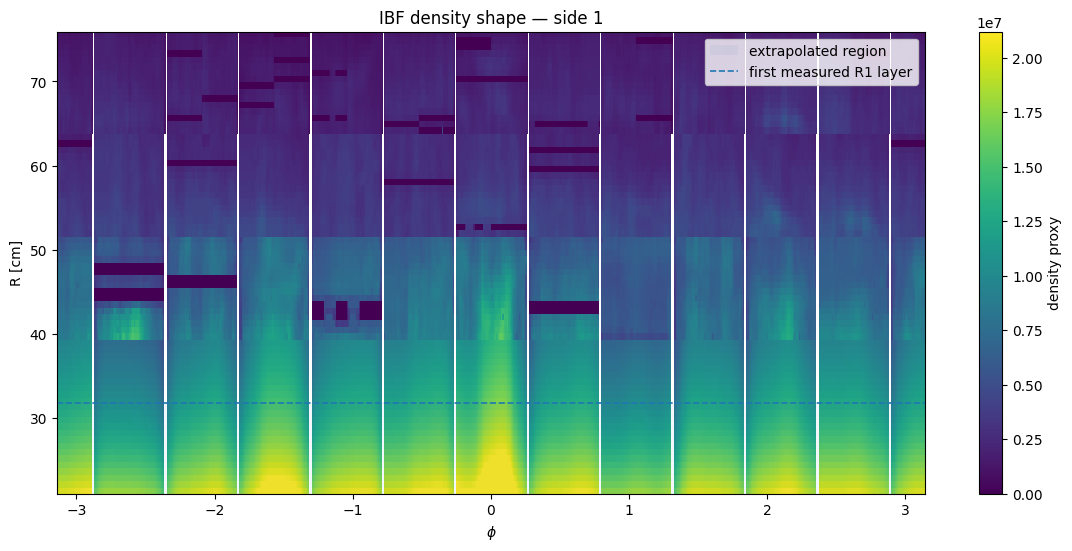

IBF side 0: radial profile alpha = 1.5376
IBF side 1: radial profile alpha = 1.9823


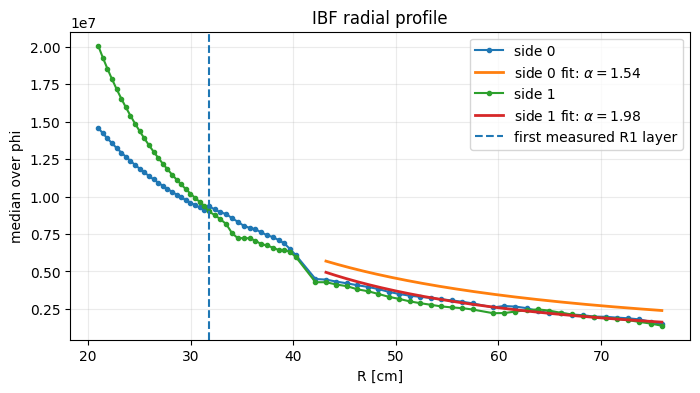

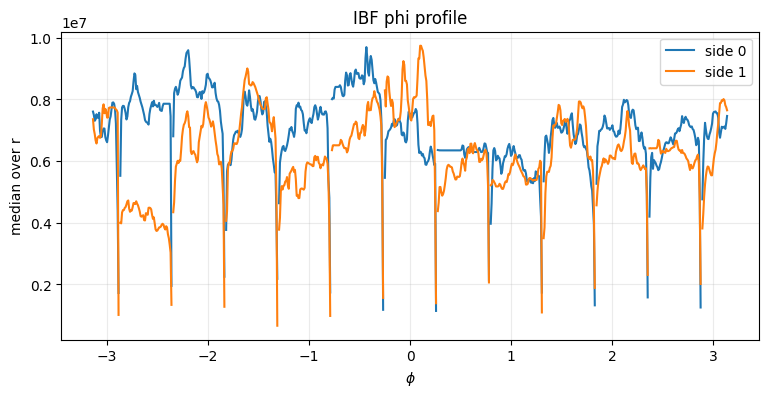

side 0: max |final - measured| above R1 boundary = 0


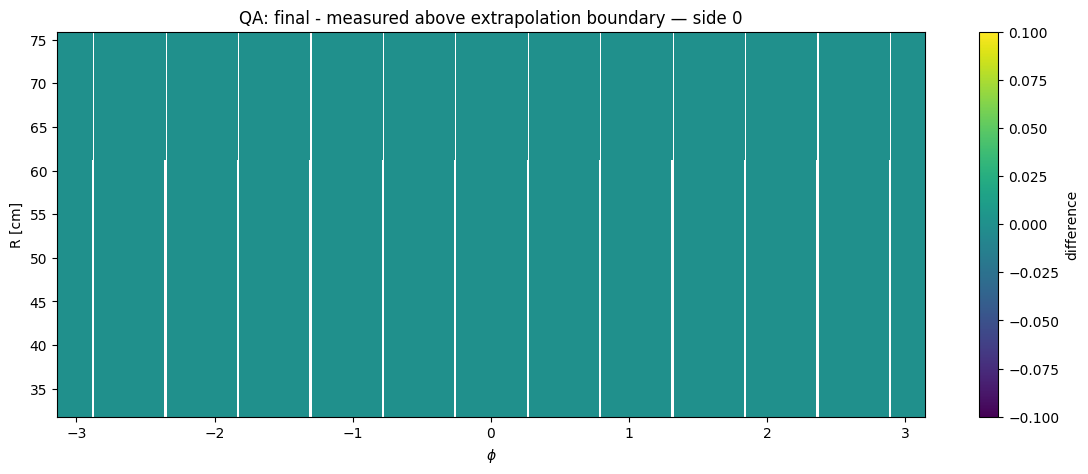

side 1: max |final - measured| above R1 boundary = 0


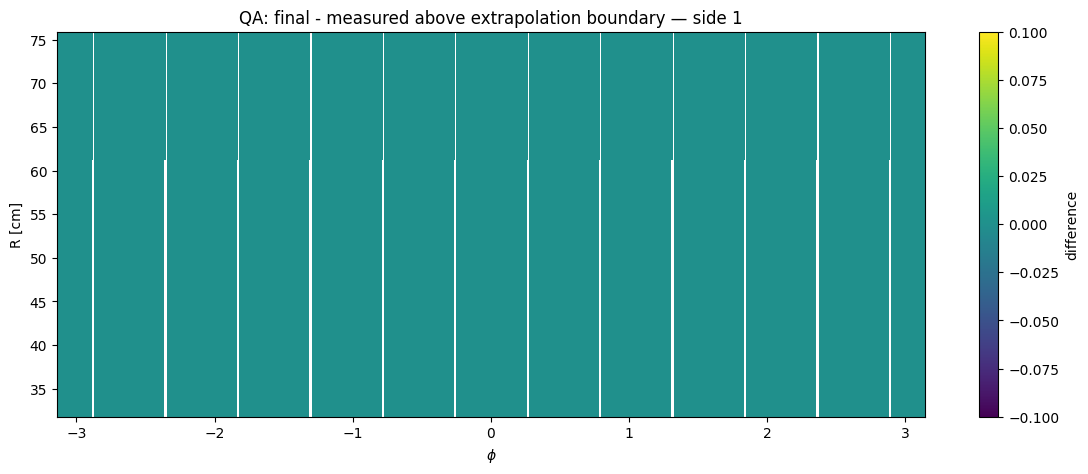

In [12]:
def save_current_figure(name):
    path=QA_PLOT_DIR/f"{name}.png"
    plt.savefig(path,dpi=160,bbox_inches="tight")
    return path

def plot_rphi(data,rvals,title,label="density proxy",save_name=None):
    finite=data[np.isfinite(data)]
    vmax=np.quantile(finite,0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(data,origin="lower",aspect="auto",extent=[PHI_MIN,PHI_MAX,rvals[0],rvals[-1]],
               vmin=0,vmax=vmax,interpolation="nearest")
    plt.xlabel(r"$\phi$"); plt.ylabel("R [cm]"); plt.title(title); plt.colorbar(label=label)
    plt.axhspan(rvals[0],all_r[0],alpha=0.06,label="extrapolated region")
    plt.axhline(all_r[0],ls="--",lw=1.2,label="first measured R1 layer")
    plt.legend()
    if save_name: save_current_figure(save_name)
    plt.show()

ibf_profile_r={}
ibf_profile_phi={}

for side in range(N_SIDES):
    plot_rphi(ibf_map[side],r_full,f"IBF density shape — side {side}",
              save_name=f"ibf_density_side{side}")
    ibf_profile_r[side]=np.nanmedian(ibf_map[side],axis=1)
    ibf_profile_phi[side]=np.nanmedian(ibf_map[side],axis=0)

# Both sides on one radial-profile canvas
plt.figure(figsize=(8,4))
for side in range(N_SIDES):
    plt.plot(r_full,ibf_profile_r[side],marker=".",label=f"side {side}")
    fit_result=fit_radial_powerlaw(r_full[17:],ibf_profile_r[side][17:],all_r[17])
    if fit_result is not None:
        A_fit,alpha_fit=fit_result
        r_curve=np.linspace(all_r[17],r_full[-1],200)
        plt.plot(r_curve,A_fit*(R_REF/r_curve)**alpha_fit,lw=2,
                 label=fr"side {side} fit: $\alpha={alpha_fit:.2f}$")
        print(f"IBF side {side}: radial profile alpha = {alpha_fit:.4f}")
plt.axvline(all_r[0],ls="--",label="first measured R1 layer")
plt.xlabel("R [cm]"); plt.ylabel("median over phi"); plt.title("IBF radial profile")
plt.grid(alpha=0.25); plt.legend()
save_current_figure("ibf_radial_profile_sides01")
plt.show()

# Both sides on one phi-profile canvas
plt.figure(figsize=(9,4))
for side in range(N_SIDES): plt.plot(phi_centers,ibf_profile_phi[side],label=f"side {side}")
plt.xlabel(r"$\phi$"); plt.ylabel("median over r"); plt.title("IBF phi profile")
plt.grid(alpha=0.25); plt.legend()
save_current_figure("ibf_phi_profile_sides01")
plt.show()

# Explicit check that measured R1/R2/R3 bins are untouched.
for side in range(N_SIDES):
    measured_slice=ibf_map[side][n_extrap:,:]
    delta=measured_slice-ibf_measured[side]
    finite=delta[np.isfinite(delta)]
    max_abs=np.max(np.abs(finite)) if finite.size else 0.0
    print(f"side {side}: max |final - measured| above R1 boundary = {max_abs:.6g}")
    plt.figure(figsize=(14,5))
    plt.imshow(delta,origin="lower",aspect="auto",extent=[PHI_MIN,PHI_MAX,all_r[0],all_r[-1]],
               interpolation="nearest")
    plt.xlabel(r"$\phi$"); plt.ylabel("R [cm]")
    plt.title(f"QA: final - measured above extrapolation boundary — side {side}")
    plt.colorbar(label="difference")
    save_current_figure(f"ibf_measured_region_difference_side{side}")
    plt.show()


## 8. Smooth 2D diagnostic fit in both r and phi

Periodic Fourier terms in phi are combined with low-order radial polynomials:

\[
\rho(r,\phi)=
\sum_k a_k r_n^k+
\sum_{n=1}^{N}\sum_k
\left[b_{nk}r_n^k\cos(n\phi)+c_{nk}r_n^k\sin(n\phi)\right].
\]

This is only a diagnostic representation. The repaired histogram can remain the
actual PHGarfield source.


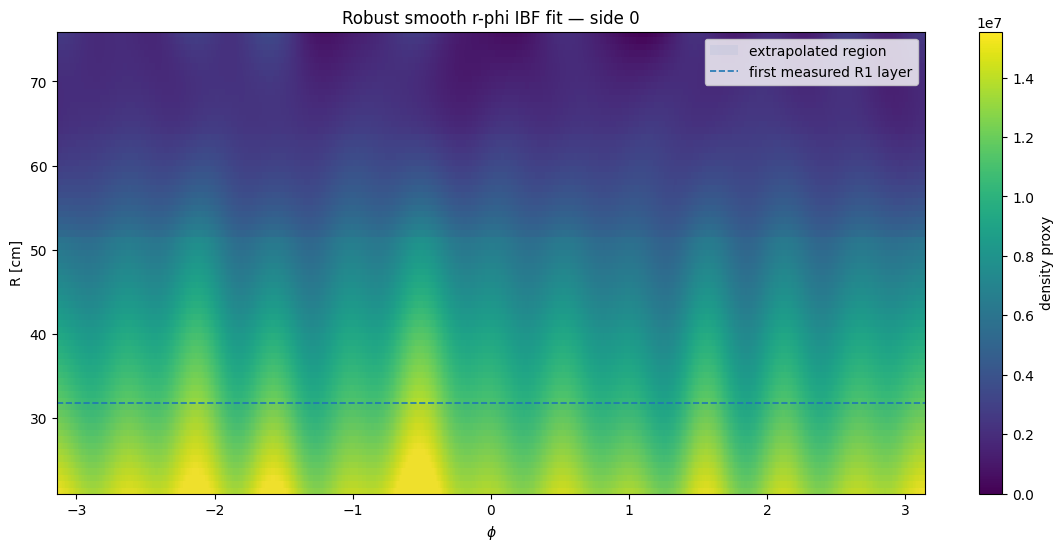

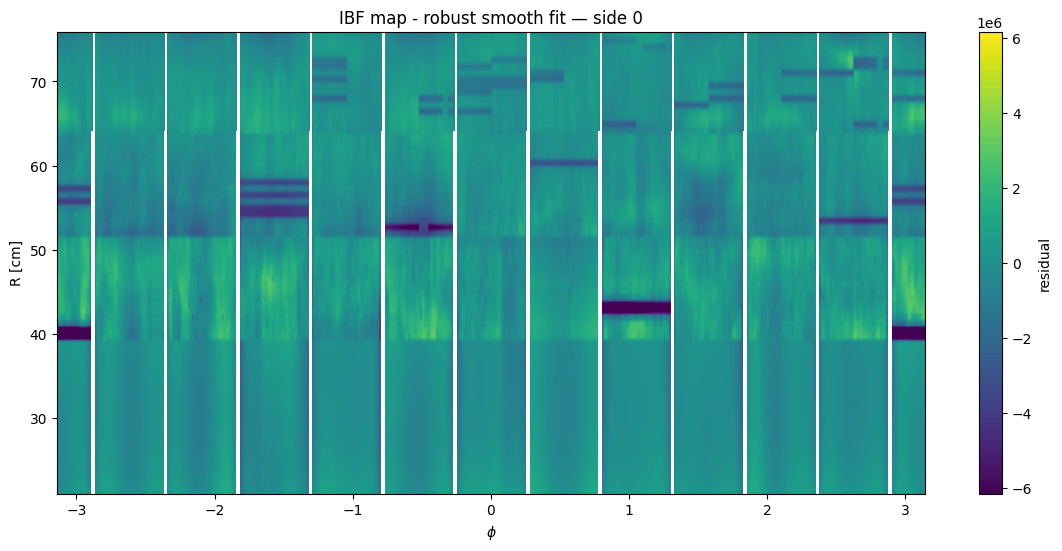

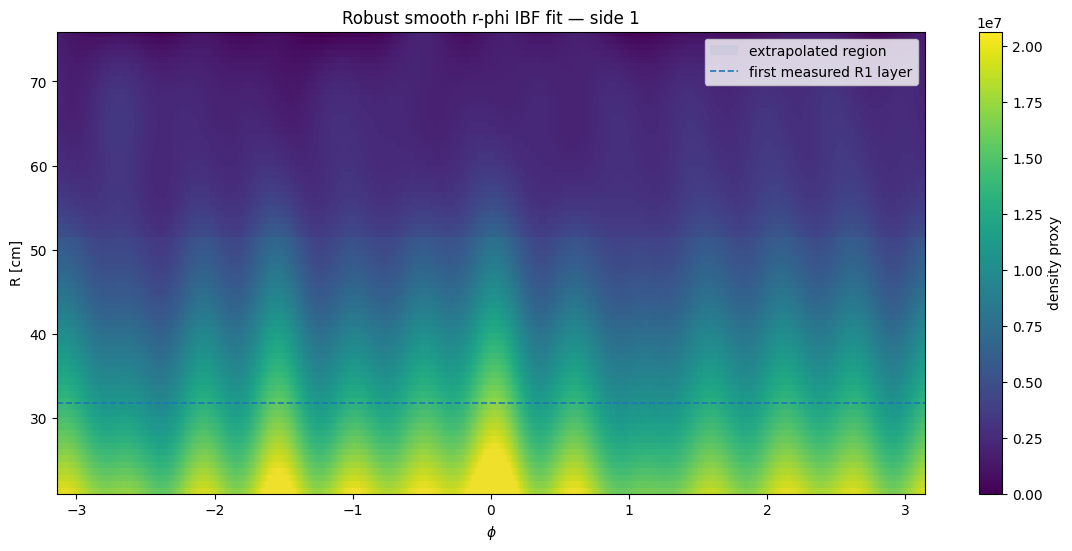

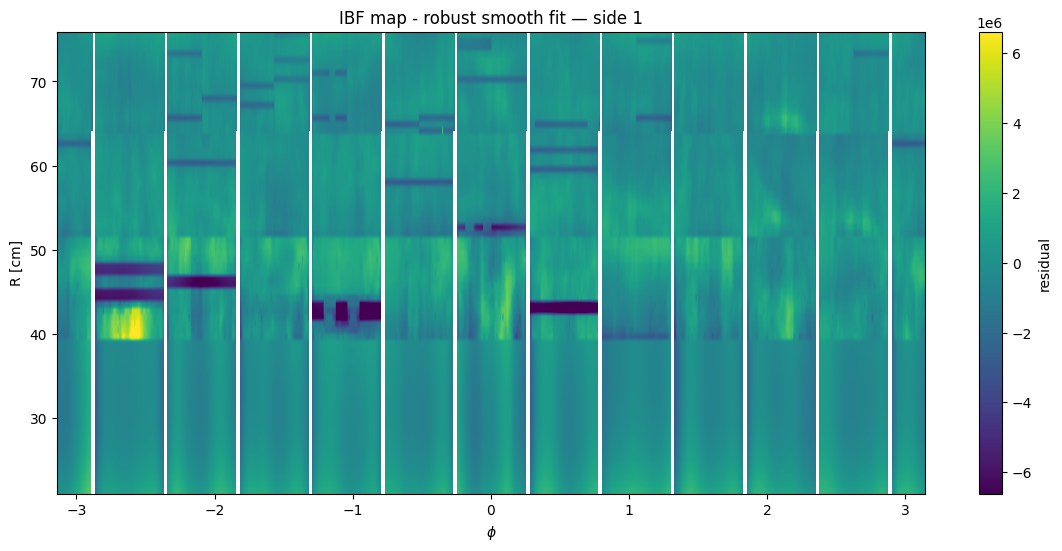

In [13]:
def design_matrix(r,phi):
    r=np.asarray(r,float)
    phi=np.asarray(phi,float)
    rmid=0.5*(r_full.min()+r_full.max())
    rscale=0.5*(r_full.max()-r_full.min())
    rn=(r-rmid)/rscale

    cols=[]
    names=[]

    for k in range(RADIAL_POLY_ORDER+1):
        cols.append(rn**k)
        names.append(f"r^{k}")

    for n in range(1,FOURIER_ORDER+1):
        for k in range(RADIAL_POLY_ORDER+1):
            cols.append((rn**k)*np.cos(n*phi))
            names.append(f"r^{k} cos({n}phi)")
        for k in range(RADIAL_POLY_ORDER+1):
            cols.append((rn**k)*np.sin(n*phi))
            names.append(f"r^{k} sin({n}phi)")

    return np.column_stack(cols),names

def fit_smooth_rphi(data,rvals,phivals):
    R,P=np.meshgrid(rvals,phivals,indexing="ij")
    y=data.ravel()
    rr=R.ravel()
    pp=P.ravel()
    good=np.isfinite(y) & (y>=FIT_MIN_DENSITY)

    X,names=design_matrix(rr[good],pp[good])
    yg=y[good]

    # Start from linear least squares.
    coef0,*_=np.linalg.lstsq(X,yg,rcond=None)

    if ROBUST_2D_FIT:
        scale=robust_scale(yg)
        if not np.isfinite(scale) or scale<=0:
            scale=max(np.nanmedian(np.abs(yg)),1.0)

        # Scale residuals so isolated hot/dead artifacts do not dominate.
        def res(c):
            return (X@c-yg)/scale

        fit=least_squares(
            res,coef0,
            loss=ROBUST_2D_LOSS,
            f_scale=1.0,
            max_nfev=40
        )
        coef=fit.x
    else:
        coef=coef0

    Xall,_=design_matrix(rr,pp)
    pred=(Xall@coef).reshape(data.shape)
    return coef,names,np.clip(pred,0,None)

ibf_fit={}
ibf_fit_coeff={}

for side in range(N_SIDES):
    coef,names,pred=fit_smooth_rphi(ibf_map[side],r_full,phi_centers)
    ibf_fit[side]=pred
    ibf_fit_coeff[side]=(coef,names)

    plot_rphi(pred,r_full,f"Robust smooth r-phi IBF fit — side {side}", save_name=f"ibf_2dfit_side{side}")

    resid=ibf_map[side]-pred
    finite=resid[np.isfinite(resid)]
    lim=np.quantile(np.abs(finite),0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(resid,origin="lower",aspect="auto",
               extent=[PHI_MIN,PHI_MAX,r_full[0],r_full[-1]],
               vmin=-lim if lim else None,vmax=lim)
    plt.xlabel(r"$\phi$")
    plt.ylabel("R [cm]")
    plt.title(f"IBF map - robust smooth fit — side {side}")
    plt.colorbar(label="residual")
    save_current_figure(f"ibf_2dfit_residual_side{side}")
    plt.show()


# Part II — primary-ionization density

The gain correction remains in native **sector × layer** coordinates before pads
are merged into `(r,phi)`.

Primary uses the same reference-radius parameterization as IBF:

\[
\rho_{\rm primary}(r,\phi)
=
\rho_{{\rm ref,primary}}(\phi)
\left(\frac{R_{\rm ref}}{r}\right)^{\alpha_{\rm primary}(\phi)}.
\]

This makes the azimuthal multiplicity term directly interpretable and prevents the
artificial large variation that appeared when plotting the old raw `A(phi)`.


PRIMARY side 0: constant alpha=1.861; final alpha=lowharmonic; final rho_ref=sector_smooth; phi damping=keep50


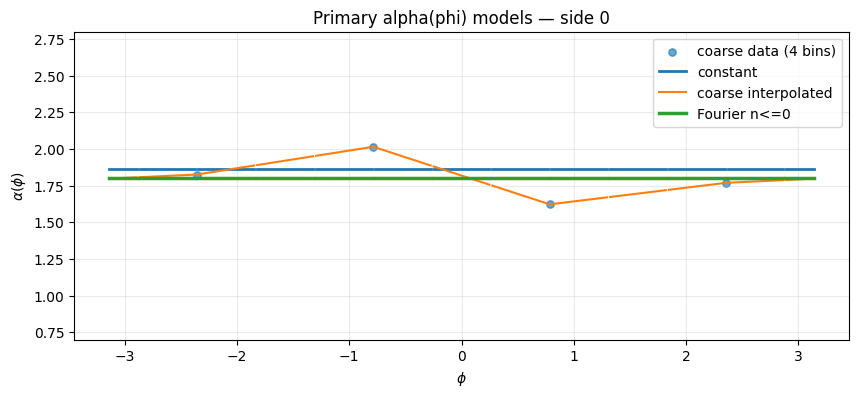

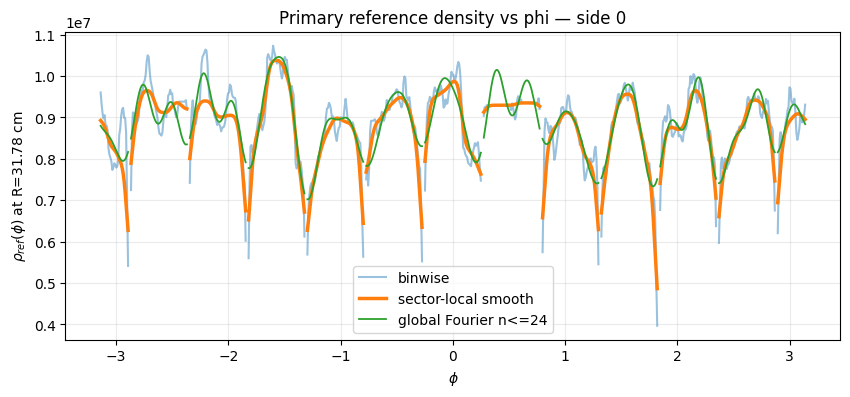

PRIMARY side 1: constant alpha=1.967; final alpha=lowharmonic; final rho_ref=sector_smooth; phi damping=keep50


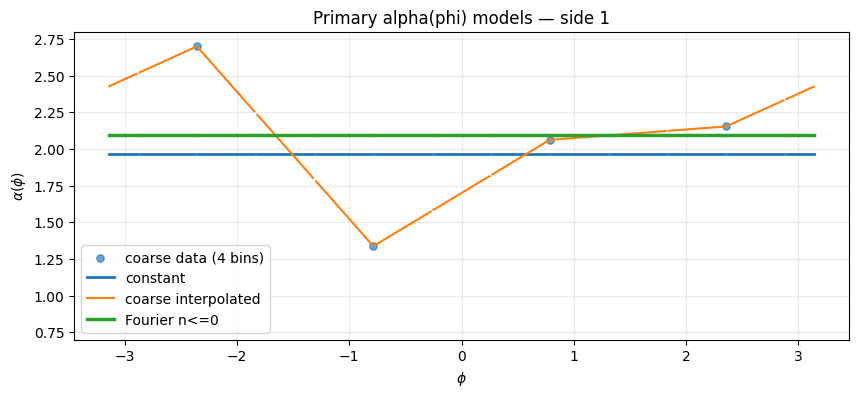

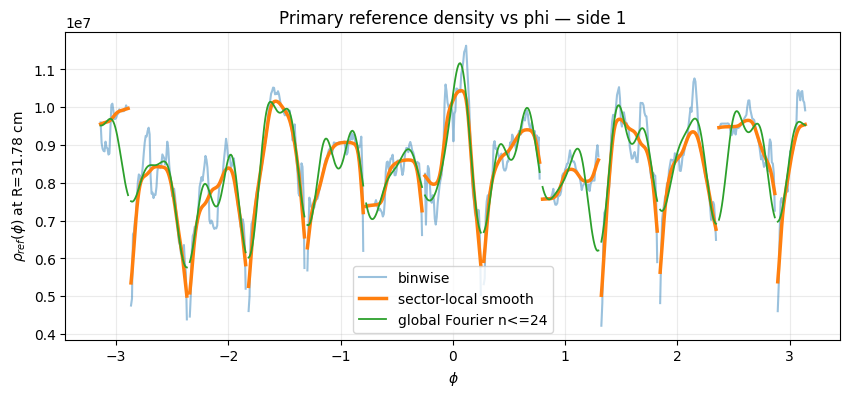

In [14]:
def get_gain_hist_name(side):
    return GAIN_MAP_HIST_SIDE0 if side==0 else GAIN_MAP_HIST_SIDE1

def load_gain_histograms():
    fg=root.TFile.Open(str(GAIN_MAP_FILE),"READ")
    if not fg or fg.IsZombie():
        raise OSError(f"Cannot open gain file: {GAIN_MAP_FILE}")

    out={}
    for side in range(N_SIDES):
        name=get_gain_hist_name(side)
        h=fg.Get(name)
        if not h:
            raise KeyError(f"Missing gain histogram: {name}")
        h=h.Clone(f"{name}_clone")
        h.SetDirectory(0)
        out[side]=h

    fg.Close()
    return out

gain_hist=load_gain_histograms()

def gain_for_sector_layer(side,sector,global_tpc_layer):
    h=gain_hist[side]
    gain_layer=global_tpc_layer-GAIN_LAYER_OFFSET
    bx=h.GetXaxis().FindBin(sector+0.5)
    by=h.GetYaxis().FindBin(gain_layer+0.5)
    g=h.GetBinContent(bx,by)
    return float(g) if np.isfinite(g) and g>0 else np.nan

def build_primary_measured_from_native(side,native_maps):
    """
    Apply gain in native sector x layer coordinates BEFORE merging into r x phi.
    """
    rho_sum=np.zeros((len(all_r),GLOBAL_PHI_BINS))
    counts=np.zeros_like(rho_sum)

    rlookup={}
    for module in range(N_MODULES):
        for il,r in enumerate(module_layer_radii_cm(module)):
            rlookup[(module,il)]=int(np.argmin(np.abs(all_r-r)))

    for module in range(N_MODULES):
        for sector in range(N_SECTORS):
            key=(side,module,sector)
            if key not in native_maps:
                continue
            a=native_maps[key]

            for il in range(LAYERS_PER_MODULE):
                glayer=global_layer(module,il)
                g=gain_for_sector_layer(side,sector,glayer)
                if not np.isfinite(g):
                    continue

                ir=rlookup[(module,il)]
                phis=sector_phi_centers(module,sector,il,side)
                bins=phi_bin_index(phis)
                area=pad_area_cm2(module,il,side)

                for ip in range(a.shape[1]):
                    val=a[il,ip]
                    if not np.isfinite(val):
                        continue

                    rho=(val/g)/area if PRIMARY_DIVIDE_BY_GAIN else val/area
                    ib=bins[ip]
                    rho_sum[ir,ib]+=rho
                    counts[ir,ib]+=1

    out=np.full_like(rho_sum,np.nan)
    good=counts>0
    out[good]=rho_sum[good]/counts[good]
    return out,counts


primary_measured={}
primary_measured_with_stripes={}
primary_coverage={}

for side in range(N_SIDES):
    primary_measured[side],primary_coverage[side]=build_primary_measured_from_native(side,model_clean_maps)
    primary_measured_with_stripes[side],_=build_primary_measured_from_native(side,primary_stripe_native_maps)

primary_family={}
primary_map={}
primary_alpha={}
primary_alpha_fit_points={}
primary_alpha_models={}
primary_rhoref_variants={}
primary_alpha_map_variants={}
primary_rhoref_map_variants={}
primary_damping_map_variants={}

for side in range(N_SIDES):
    fam=construct_extrapolation_family(
        primary_measured[side],primary_coverage[side],
        repair_fraction_measured[side],all_r,side,"Primary"
    )

    primary_family[side]=fam
    primary_map[side]=fam["final_map"].copy()
    # Second primary copy: identical clean extrapolation, but measured dead
    # stripes are restored above the first measured R1 layer.
    if "primary_map_with_stripes" not in globals(): primary_map_with_stripes={}
    primary_map_with_stripes[side]=fam["final_map"].copy()
    primary_map_with_stripes[side][fam["n_extrap"]:,:]=primary_measured_with_stripes[side]
    primary_alpha[side]=fam["alpha0"]
    primary_alpha_fit_points[side]=fam["alpha_fitpts"]
    primary_alpha_models[side]=fam["alpha_models"]
    primary_rhoref_variants[side]=fam["rhoref_models"]
    primary_alpha_map_variants[side]=fam["alpha_maps"]
    primary_rhoref_map_variants[side]=fam["rhoref_maps"]
    primary_damping_map_variants[side]=fam["damping_maps"]
    r_primary=fam["r_full"]

    print(
        f"PRIMARY side {side}: constant alpha={fam['alpha0']:.3f}; "
        f"final alpha={ALPHA_PHI_FINAL}; final rho_ref={RHOREF_PHI_FINAL}; "
        f"phi damping={fam['final_damping_tag']}"
    )

    plt.figure(figsize=(10,4))
    good=np.isfinite(fam["alpha_coarse_raw"])
    plt.scatter(
        fam["alpha_coarse_phi"][good],
        fam["alpha_coarse_raw"][good],
        s=28,alpha=0.65,label=f"coarse data ({ALPHA_N_PHI_BINS} bins)"
    )
    plt.plot(phi_centers,fam["alpha_models"]["constant"],
             label="constant",lw=2)
    plt.plot(phi_centers,fam["alpha_models"]["coarse"],
             label="coarse interpolated",lw=1.5)
    plt.plot(phi_centers,fam["alpha_models"]["lowharmonic"],
             label=f"Fourier n<={ALPHA_LOW_HARMONIC}",lw=2.5)
    plt.ylim(ALPHA_BOUNDS[0]-0.1,ALPHA_BOUNDS[1]+0.1)
    plt.xlabel(r"$\phi$")
    plt.ylabel(r"$\alpha(\phi)$")
    plt.title(f"Primary alpha(phi) models — side {side}")
    plt.grid(alpha=0.25); plt.legend()
    plt.savefig(QA_PLOT_DIR/f"primary_alpha_phi_models_side{side}.png",
                dpi=160,bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(phi_centers,fam["rhoref_models"]["binwise"],
             label="binwise",alpha=0.45)
    plt.plot(phi_centers,fam["rhoref_models"]["sector_smooth"],
             label="sector-local smooth",lw=2.5)
    plt.plot(phi_centers,fam["rhoref_models"]["highharmonic"],
             label=f"global Fourier n<={RHOREF_HIGH_HARMONIC}",lw=1.3)
    plt.xlabel(r"$\phi$")
    plt.ylabel(fr"$\rho_{{ref}}(\phi)$ at R={R_REF:.2f} cm")
    plt.title(f"Primary reference density vs phi — side {side}")
    plt.grid(alpha=0.25); plt.legend()
    plt.savefig(QA_PLOT_DIR/f"primary_rhoref_models_side{side}.png",
                dpi=160,bbox_inches="tight")
    plt.show()

assert np.allclose(r_primary,r_full)


## Primary maps, profiles, and 2D fits

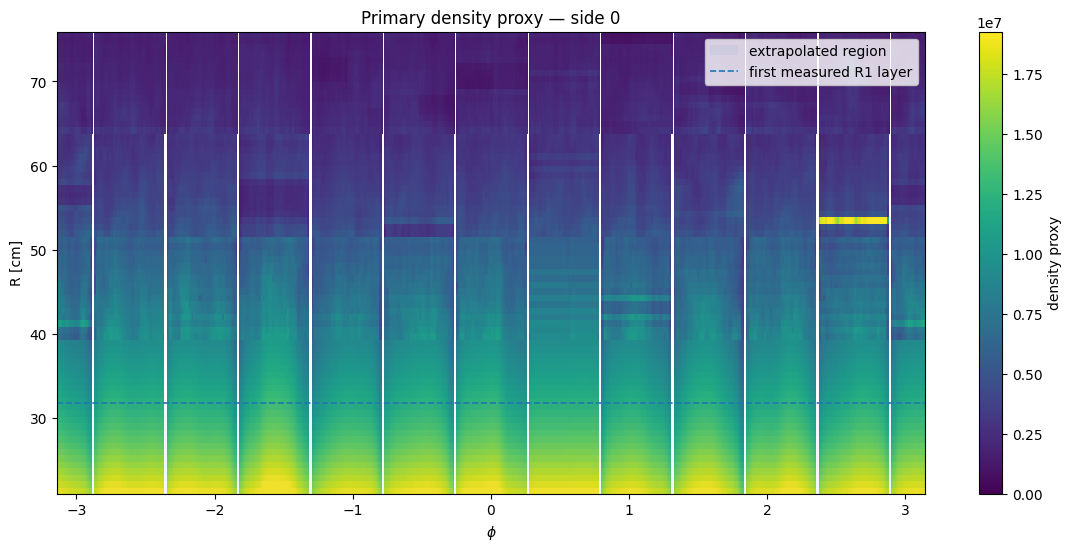

/tmp/ipykernel_64145/2159400868.py:10: RuntimeWarning: All-NaN slice encountered
  primary_profile_phi[side]=np.nanmedian(primary_map[side],axis=0)


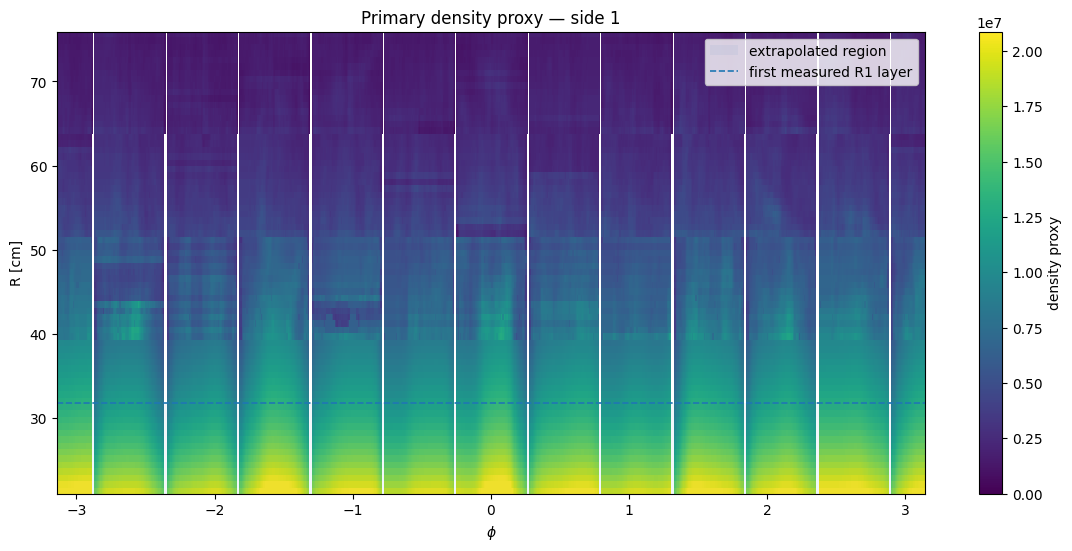

Primary side 0: radial profile alpha = 1.8022
Primary side 1: radial profile alpha = 2.0947


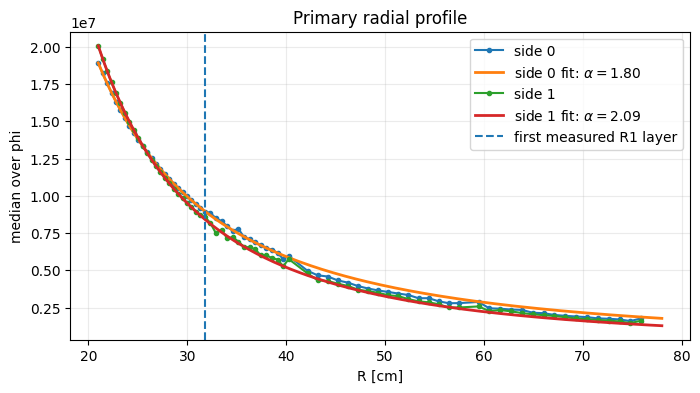

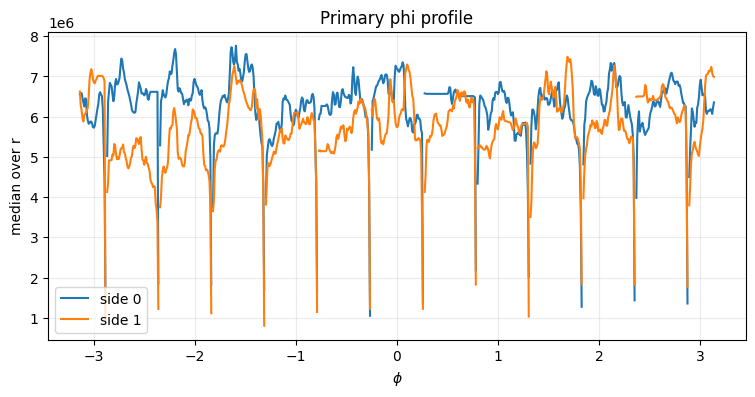

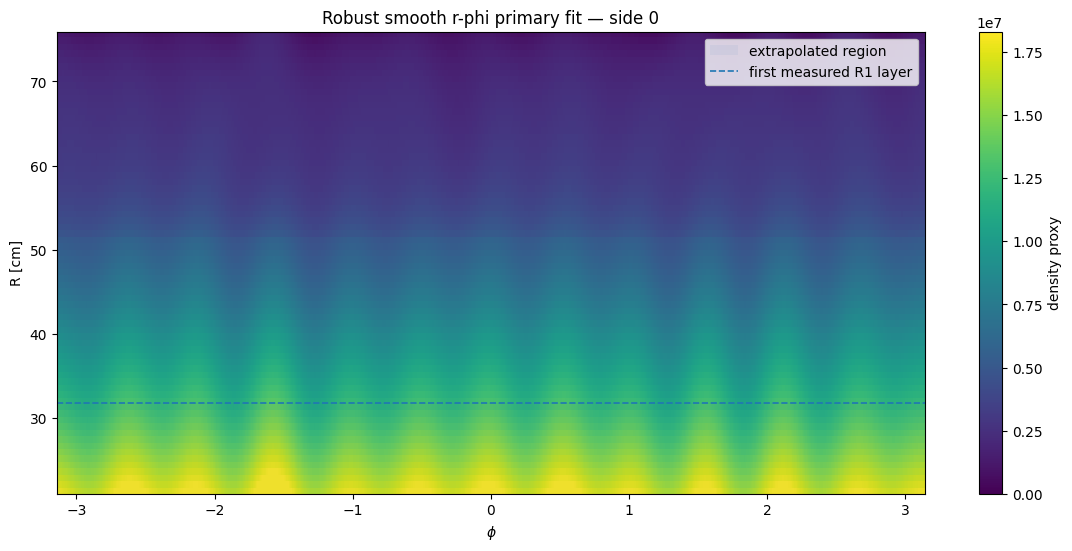

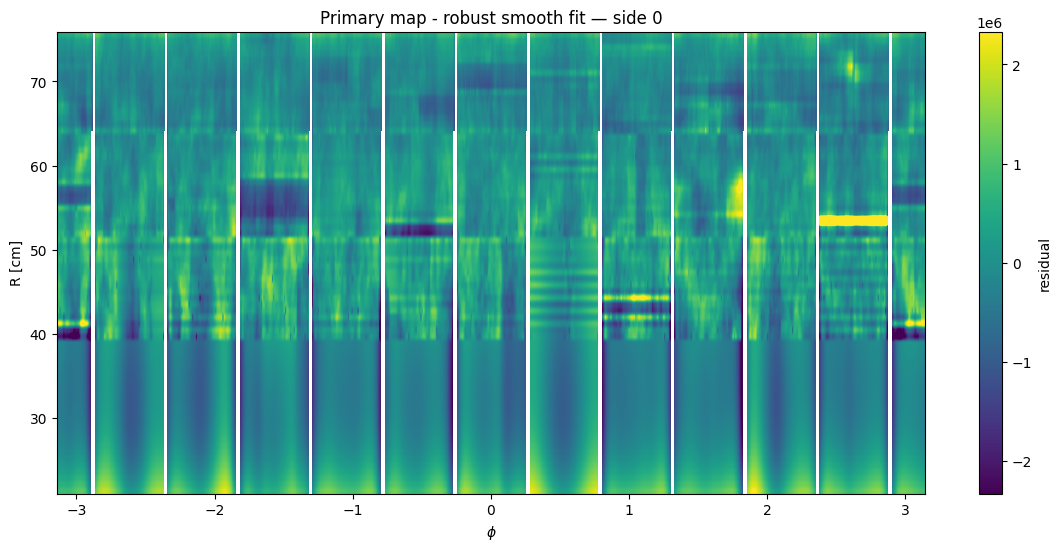

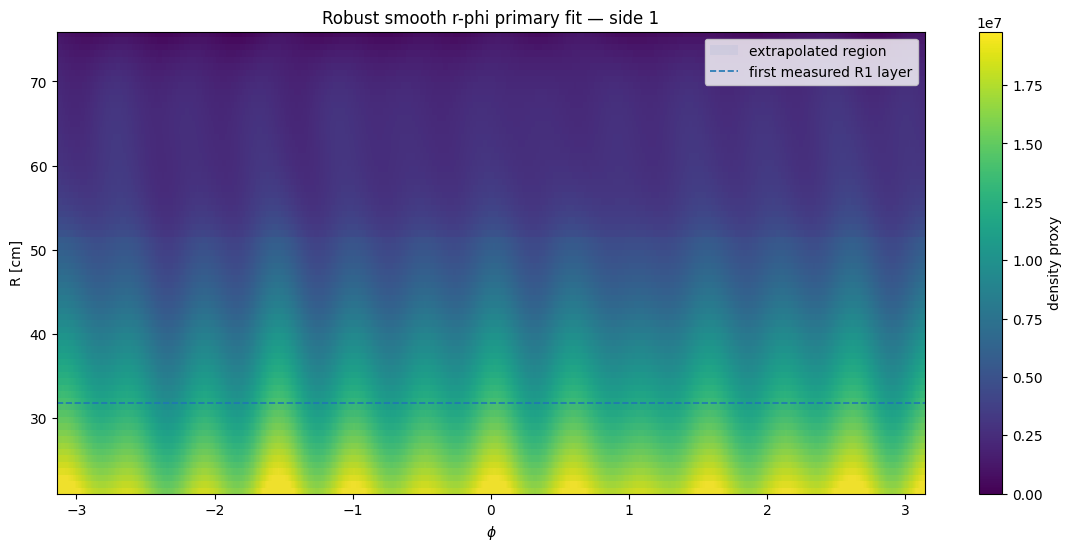

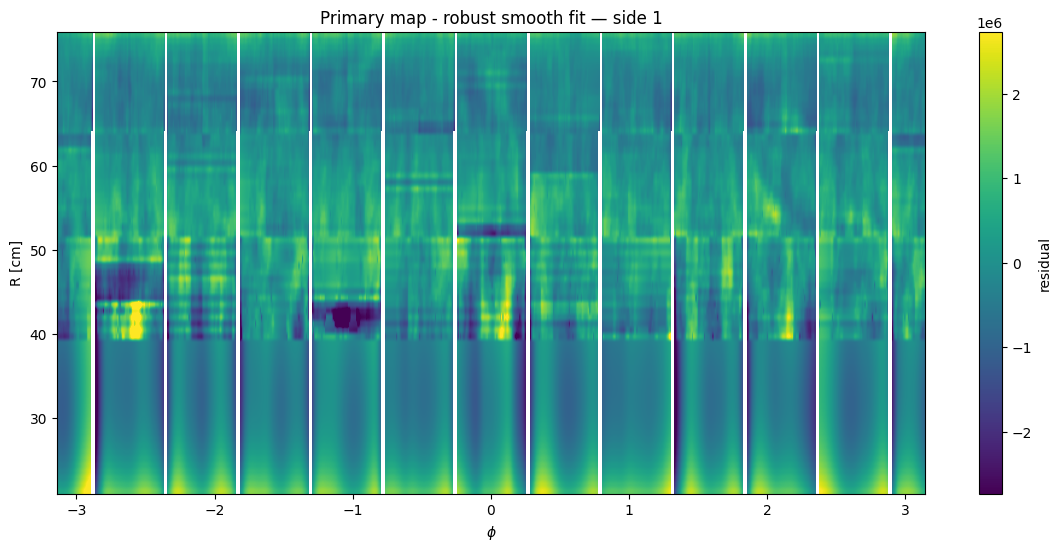

In [15]:
primary_fit={}
primary_fit_coeff={}
primary_profile_r={}
primary_profile_phi={}

for side in range(N_SIDES):
    plot_rphi(primary_map[side],r_full,f"Primary density proxy — side {side}",
              save_name=f"primary_density_side{side}")
    primary_profile_r[side]=np.nanmedian(primary_map[side],axis=1)
    primary_profile_phi[side]=np.nanmedian(primary_map[side],axis=0)

# Both sides on one radial-profile canvas
plt.figure(figsize=(8,4))
for side in range(N_SIDES):
    plt.plot(r_full,primary_profile_r[side],marker=".",label=f"side {side}")
    fit_result=fit_radial_powerlaw(r_full,primary_profile_r[side],all_r[0])
    if fit_result is not None:
        A_fit,alpha_fit=fit_result
        r_curve=np.linspace(IFC_RADIUS_CM,78,200)
        plt.plot(r_curve,A_fit*(R_REF/r_curve)**alpha_fit,lw=2,
                 label=fr"side {side} fit: $\alpha={alpha_fit:.2f}$")
        print(f"Primary side {side}: radial profile alpha = {alpha_fit:.4f}")
plt.axvline(all_r[0],ls="--",label="first measured R1 layer")
plt.xlabel("R [cm]"); plt.ylabel("median over phi"); plt.title("Primary radial profile")
plt.grid(alpha=0.25); plt.legend()
save_current_figure("primary_radial_profile_sides01")
plt.show()

# Both sides on one phi-profile canvas
plt.figure(figsize=(9,4))
for side in range(N_SIDES): plt.plot(phi_centers,primary_profile_phi[side],label=f"side {side}")
plt.xlabel(r"$\phi$"); plt.ylabel("median over r"); plt.title("Primary phi profile")
plt.grid(alpha=0.25); plt.legend()
save_current_figure("primary_phi_profile_sides01")
plt.show()

for side in range(N_SIDES):
    coef,names,pred=fit_smooth_rphi(primary_map[side],r_full,phi_centers)
    primary_fit[side]=pred
    primary_fit_coeff[side]=(coef,names)
    plot_rphi(pred,r_full,f"Robust smooth r-phi primary fit — side {side}",
              save_name=f"primary_2dfit_side{side}")

    resid=primary_map[side]-pred
    finite=resid[np.isfinite(resid)]
    lim=np.quantile(np.abs(finite),0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(resid,origin="lower",aspect="auto",extent=[PHI_MIN,PHI_MAX,r_full[0],r_full[-1]],
               vmin=-lim if lim else None,vmax=lim)
    plt.xlabel(r"$\phi$"); plt.ylabel("R [cm]")
    plt.title(f"Primary map - robust smooth fit — side {side}")
    plt.colorbar(label="residual")
    save_current_figure(f"primary_2dfit_residual_side{side}")
    plt.show()


## Save the final maps to ROOT

In [16]:
def centers_to_edges(x):
    x=np.asarray(x,float)
    e=np.empty(len(x)+1)
    e[1:-1]=0.5*(x[:-1]+x[1:])
    e[0]=x[0]-0.5*(x[1]-x[0])
    e[-1]=x[-1]+0.5*(x[-1]-x[-2])
    return e

def numpy_to_th2(name,title,data,rvals):
    pedges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
    redges=centers_to_edges(rvals)
    h=root.TH2D(
        name,title,
        GLOBAL_PHI_BINS,array("d",pedges),
        len(rvals),array("d",redges)
    )
    h.SetDirectory(0)

    for ir in range(len(rvals)):
        for ip in range(GLOBAL_PHI_BINS):
            v=data[ir,ip]
            h.SetBinContent(ip+1,ir+1,float(v) if np.isfinite(v) else 0.0)
    return h

def numpy_to_th1_centers(name,title,values,centers,xlabel,ylabel):
    edges=centers_to_edges(centers)
    h=root.TH1D(name,f"{title};{xlabel};{ylabel}",len(centers),array("d",edges))
    h.SetDirectory(0)
    for i,v in enumerate(values):
        h.SetBinContent(i+1,float(v) if np.isfinite(v) else 0.0)
    return h

def phi_profile_to_th1(name,title,values,ylabel="value"):
    edges=np.linspace(PHI_MIN,PHI_MAX,len(values)+1)
    h=root.TH1D(name,f"{title};#phi;{ylabel}",len(values),array("d",edges))
    h.SetDirectory(0)
    for i,v in enumerate(values):
        h.SetBinContent(i+1,float(v) if np.isfinite(v) else 0.0)
    return h

def fit_points_to_graph(name,fitpts):
    fr,fy,fs,fw=fitpts
    g=root.TGraphErrors(len(fr))
    g.SetName(name)
    g.SetTitle(name)
    for i,(r,y,s) in enumerate(zip(fr,fy,fs)):
        g.SetPoint(i,float(r),float(y))
        g.SetPointError(i,0.0,float(y*s))
    return g

def coarse_alpha_graph(name,phi,alpha):
    good=np.isfinite(alpha)
    g=root.TGraph(np.count_nonzero(good))
    g.SetName(name)
    g.SetTitle(name)
    j=0
    for x,y in zip(phi[good],alpha[good]):
        g.SetPoint(j,float(x),float(y))
        j+=1
    return g


# ============================================================
# Main physics maps
# ============================================================
fout=root.TFile.Open(str(OUTPUT_ROOT),"RECREATE")

for side in range(N_SIDES):
    objects=[
        numpy_to_th2(
            f"h_ibf_final_rphi_side{side}",
            f"Final IBF density side {side};#phi;R [cm];arb. density",
            ibf_map[side],r_full
        ),
        numpy_to_th2(
            f"h_ibf_underlying_clean_rphi_side{side}",
            f"Underlying clean IBF density side {side};#phi;R [cm];arb. density",
            ibf_family[side]["final_map"],r_full
        ),
        numpy_to_th2(
            f"h_ibf_alpha_constant_rphi_side{side}",
            f"IBF constant alpha side {side};#phi;R [cm];arb. density",
            ibf_alpha_map_variants[side]["constant"],r_full
        ),
        numpy_to_th2(
            f"h_ibf_alpha_coarse_rphi_side{side}",
            f"IBF coarse alpha(phi) side {side};#phi;R [cm];arb. density",
            ibf_alpha_map_variants[side]["coarse"],r_full
        ),
        numpy_to_th2(
            f"h_ibf_alpha_lowharmonic_rphi_side{side}",
            f"IBF low-harmonic alpha(phi) side {side};#phi;R [cm];arb. density",
            ibf_alpha_map_variants[side]["lowharmonic"],r_full
        ),
        numpy_to_th2(
            f"h_ibf_rhoref_sector_smooth_rphi_side{side}",
            f"IBF sector-smoothed rho_ref side {side};#phi;R [cm];arb. density",
            ibf_rhoref_map_variants[side]["sector_smooth"],r_full
        ),
        numpy_to_th2(
            f"h_ibf_density_fit_rphi_side{side}",
            f"Robust smooth IBF fit side {side};#phi;R [cm];arb. density",
            ibf_fit[side],r_full
        ),
        numpy_to_th2(
            f"h_primary_final_rphi_side{side}",
            f"Final primary density side {side};#phi;R [cm];arb. density",
            primary_map[side],r_full
        ),
        numpy_to_th2(
            f"h_primary_final_with_dead_stripes_rphi_side{side}",
            f"Primary density with measured dead stripes side {side};#phi;R [cm];arb. density",
            primary_map_with_stripes[side],r_full
        ),
        numpy_to_th2(
            f"h_primary_density_fit_rphi_side{side}",
            f"Robust smooth primary fit side {side};#phi;R [cm];arb. density",
            primary_fit[side],r_full
        ),
    ]

    for h in objects:
        h.Write()

fout.Close()


# ============================================================
# QA ROOT
# ============================================================
fqa=root.TFile.Open(str(QA_ROOT),"RECREATE")

for side in range(N_SIDES):
    # measured maps
    numpy_to_th2(
        f"h_ibf_measured_side{side}",
        f"Measured IBF proxy side {side};#phi;R [cm];arb.",
        ibf_measured[side],all_r
    ).Write()

    numpy_to_th2(
        f"h_primary_measured_side{side}",
        f"Measured primary proxy side {side};#phi;R [cm];arb.",
        primary_measured[side],all_r
    ).Write()

    numpy_to_th2(
        f"h_primary_measured_with_dead_stripes_side{side}",
        f"Measured primary proxy with dead stripes side {side};#phi;R [cm];arb.",
        primary_measured_with_stripes[side],all_r
    ).Write()

    numpy_to_th2(
        f"h_repair_fraction_side{side}",
        f"Repair fraction side {side};#phi;R [cm];fraction",
        repair_fraction_measured[side],all_r
    ).Write()

    hg=gain_hist[side].Clone(f"h_gain_sector_layer_side{side}")
    hg.SetDirectory(0)
    hg.Write()

    # alpha(phi) variants
    for mode in ("constant","coarse","lowharmonic"):
        numpy_to_th2(
            f"h_ibf_extrap_alpha_{mode}_side{side}",
            f"IBF extrapolation alpha={mode} side {side};#phi;R [cm];arb.",
            ibf_alpha_map_variants[side][mode],r_full
        ).Write()

        numpy_to_th2(
            f"h_primary_extrap_alpha_{mode}_side{side}",
            f"Primary extrapolation alpha={mode} side {side};#phi;R [cm];arb.",
            primary_alpha_map_variants[side][mode],r_full
        ).Write()

        phi_profile_to_th1(
            f"h_ibf_alpha_phi_{mode}_side{side}",
            f"IBF alpha(phi) {mode} side {side}",
            ibf_alpha_models[side][mode],
            "alpha"
        ).Write()

        phi_profile_to_th1(
            f"h_primary_alpha_phi_{mode}_side{side}",
            f"Primary alpha(phi) {mode} side {side}",
            primary_alpha_models[side][mode],
            "alpha"
        ).Write()

    # coarse alpha points themselves
    coarse_alpha_graph(
        f"g_ibf_alpha_coarse_points_side{side}",
        ibf_family[side]["alpha_coarse_phi"],
        ibf_family[side]["alpha_coarse_raw"]
    ).Write()

    coarse_alpha_graph(
        f"g_primary_alpha_coarse_points_side{side}",
        primary_family[side]["alpha_coarse_phi"],
        primary_family[side]["alpha_coarse_raw"]
    ).Write()

    phi_profile_to_th1(
        f"h_ibf_rhoref_npoints_side{side}",
        f"IBF number of R1 layers used for rho_ref side {side}",
        ibf_family[side]["rhoref_n_used"],
        "N R1 layers"
    ).Write()

    phi_profile_to_th1(
        f"h_primary_rhoref_npoints_side{side}",
        f"Primary number of R1 layers used for rho_ref side {side}",
        primary_family[side]["rhoref_n_used"],
        "N R1 layers"
    ).Write()

    # rho_ref(phi) variants
    for mode in ("binwise","sector_smooth","highharmonic"):
        numpy_to_th2(
            f"h_ibf_extrap_rhoref_{mode}_side{side}",
            f"IBF extrapolation rho_ref={mode} side {side};#phi;R [cm];arb.",
            ibf_rhoref_map_variants[side][mode],r_full
        ).Write()

        numpy_to_th2(
            f"h_primary_extrap_rhoref_{mode}_side{side}",
            f"Primary extrapolation rho_ref={mode} side {side};#phi;R [cm];arb.",
            primary_rhoref_map_variants[side][mode],r_full
        ).Write()

        phi_profile_to_th1(
            f"h_ibf_rhoref_phi_{mode}_side{side}",
            f"IBF rho_ref(phi) {mode} side {side}",
            ibf_rhoref_variants[side][mode],
            "rho_ref"
        ).Write()

        phi_profile_to_th1(
            f"h_primary_rhoref_phi_{mode}_side{side}",
            f"Primary rho_ref(phi) {mode} side {side}",
            primary_rhoref_variants[side][mode],
            "rho_ref"
        ).Write()

    numpy_to_th2(
        f"h_ibf_measured_region_difference_side{side}",
        f"Final-minus-measured IBF above R1 boundary side {side};#phi;R [cm];difference",
        ibf_map[side][n_extrap:,:]-ibf_measured[side],all_r
    ).Write()

    # inward phi-modulation damping variants
    for tag,frac in ibf_family[side]["damping_labels"].items():
        numpy_to_th2(
            f"h_ibf_extrap_damping_{tag}_side{side}",
            f"IBF phi damping {tag} side {side};#phi;R [cm];arb.",
            ibf_damping_map_variants[side][tag],r_full
        ).Write()

        numpy_to_th2(
            f"h_primary_extrap_damping_{tag}_side{side}",
            f"Primary phi damping {tag} side {side};#phi;R [cm];arb.",
            primary_damping_map_variants[side][tag],r_full
        ).Write()

    # final maps / fits / residuals
    numpy_to_th2(
        f"h_ibf_final_side{side}",
        f"Final IBF side {side};#phi;R [cm];arb.",
        ibf_map[side],r_full
    ).Write()

    numpy_to_th2(
        f"h_ibf_fit_side{side}",
        f"IBF 2D fit side {side};#phi;R [cm];arb.",
        ibf_fit[side],r_full
    ).Write()

    numpy_to_th2(
        f"h_ibf_fit_residual_side{side}",
        f"IBF fit residual side {side};#phi;R [cm];data-fit",
        ibf_map[side]-ibf_fit[side],r_full
    ).Write()

    numpy_to_th2(
        f"h_primary_final_side{side}",
        f"Final primary side {side};#phi;R [cm];arb.",
        primary_map[side],r_full
    ).Write()

    numpy_to_th2(
        f"h_primary_fit_side{side}",
        f"Primary 2D fit side {side};#phi;R [cm];arb.",
        primary_fit[side],r_full
    ).Write()

    numpy_to_th2(
        f"h_primary_fit_residual_side{side}",
        f"Primary fit residual side {side};#phi;R [cm];data-fit",
        primary_map[side]-primary_fit[side],r_full
    ).Write()

    # 1D QA profiles
    numpy_to_th1_centers(
        f"h_ibf_profile_r_side{side}",
        f"IBF radial profile side {side}",
        ibf_profile_r[side],r_full,
        "R [cm]","median over #phi"
    ).Write()

    phi_profile_to_th1(
        f"h_ibf_profile_phi_side{side}",
        f"IBF phi profile side {side}",
        ibf_profile_phi[side],
        "median density"
    ).Write()

    numpy_to_th1_centers(
        f"h_primary_profile_r_side{side}",
        f"Primary radial profile side {side}",
        primary_profile_r[side],r_full,
        "R [cm]","median over #phi"
    ).Write()

    phi_profile_to_th1(
        f"h_primary_profile_phi_side{side}",
        f"Primary phi profile side {side}",
        primary_profile_phi[side],
        "median density"
    ).Write()

    fit_points_to_graph(
        f"g_ibf_alpha_radial_fit_points_side{side}",
        ibf_alpha_fit_points[side]
    ).Write()

    fit_points_to_graph(
        f"g_primary_alpha_radial_fit_points_side{side}",
        primary_alpha_fit_points[side]
    ).Write()

    root.TParameter("double")(
        f"ibf_alpha_constant_side{side}",float(ibf_alpha[side])
    ).Write()

    root.TParameter("double")(
        f"primary_alpha_constant_side{side}",float(primary_alpha[side])
    ).Write()

    root.TParameter("double")(
        f"R_REF_CM_side{side}",float(R_REF)
    ).Write()


# ============================================================
# Native sector QA
# ============================================================
dsec=fqa.mkdir("sector_maps")
dsec.cd()

for (side,module,sector),item in raw_maps.items():
    raw=item["adc"]
    rep=ibf_native_maps[(side,module,sector)]
    model=model_clean_maps[(side,module,sector)]
    mask=repair_masks[(side,module,sector)].astype(float)
    stripe=stripe_masks[(side,module,sector)].astype(float)

    nx=raw.shape[1]
    ny=raw.shape[0]

    for arr,tag in [
        (raw,"raw"),
        (model,"underlying_clean"),
        (rep,"ibf_with_dead_stripes"),
        (mask,"repairmask"),
        (stripe,"deadstripe_mask"),
        (model-raw,"recovery_difference")
    ]:
        name=f"h_{tag}_side{side}_sec{sector:02d}_R{module+1}"
        h=root.TH2D(name,f"{tag};local pad;local layer",nx,0,nx,ny,0,ny)
        for iy in range(ny):
            for ix in range(nx):
                v=arr[iy,ix]
                h.SetBinContent(ix+1,iy+1,float(v) if np.isfinite(v) else 0.0)
        h.Write()

fqa.Close()

print("Wrote main maps:",OUTPUT_ROOT)
print("Wrote QA ROOT:",QA_ROOT)
print("Saved QA PNGs under:",QA_PLOT_DIR)


Wrote main maps: output/TPC_IBF_primary_maps.root
Wrote QA ROOT: output/TPC_IBF_primary_QA.root
Saved QA PNGs under: output/qa_plots


## v11 source-model logic

The output now separates detector defects from the physical source:

- **FEE / irregular dead blocks / single hot or dead channels:** reconstructed.
- **Dead stripes:** reconstructed for extrapolation and for the clean primary map,
  but restored to the measured values in the final IBF map.
- **Primary:** two copies are written:
  - `h_primary_final_rphi_side0/1` — stripes reconstructed;
  - `h_primary_final_with_dead_stripes_rphi_side0/1` — measured stripes restored.
- **IBF:** `h_ibf_final_rphi_side0/1` keeps measured dead stripes, while
  `h_ibf_underlying_clean_rphi_side0/1` is available as QA.

All robust smoothing is performed in native sector coordinates, so sector boundaries
are never averaged together. The inward extrapolation is derived only from the
fully recovered and smoothed physical source.


In [17]:
def run_batch(input_files=BATCH_INPUT_ROOTS,notebook=NOTEBOOK_FILE):
    """Execute this notebook once per input ROOT file, writing tagged outputs."""
    if IS_BATCH_CHILD:
        print("Batch child: skipping run_batch() to avoid recursive nbconvert execution")
        return
    if not input_files:
        print("BATCH_INPUT_ROOTS is empty")
        return

    notebook=Path(notebook).resolve()
    if not notebook.exists(): raise FileNotFoundError(f"Notebook not found: {notebook}")

    for infile in input_files:
        infile=Path(infile).resolve()
        tag=infile.stem
        env=os.environ.copy()
        env["TPC_DENSITY_INPUT"]=str(infile)
        env["TPC_DENSITY_TAG"]=tag
        env["TPC_DENSITY_BATCH_CHILD"]="1"

        executed=(OUTPUT_DIR/f"executed_{tag}.ipynb").resolve()
        executed.parent.mkdir(parents=True,exist_ok=True)
        print("Running",infile,"->",executed)

        cmd=["jupyter","nbconvert","--to","notebook","--execute",str(notebook),
             "--output",executed.name,"--output-dir",str(executed.parent),
             "--ExecutePreprocessor.timeout=-1"]
        result=subprocess.run(cmd,env=env,text=True,capture_output=True)
        if result.returncode:
            print(result.stdout)
            print(result.stderr)
            raise RuntimeError(f"Batch execution failed for {infile} (exit {result.returncode})")

# Example:
# BATCH_INPUT_ROOTS=["input/qa/QA_79514.root","input/qa/QA_79515.root"]
run_batch()


Running /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/input/qa/QA1_79513.root -> /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/output/executed_QA1_79513.ipynb
Running /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/input/qa/QA1_79507.root -> /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/output/executed_QA1_79507.ipynb
Running /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/input/qa/QA1_79514.root -> /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/output/executed_QA1_79514.ipynb
Running /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/input/qa/QA1_79515.root -> /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/output/executed_QA1_79515.ipynb
Running /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/input/qa/QA1_79516.root -> /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/current/output/executed_QA1_79516.ipynb
Running /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/curre

/tmp/ipykernel_64145/1542875555.py:10: RuntimeWarning: All-NaN slice encountered
  return r,phi,np.nanmedian(a,axis=1),np.nanmedian(a,axis=0)


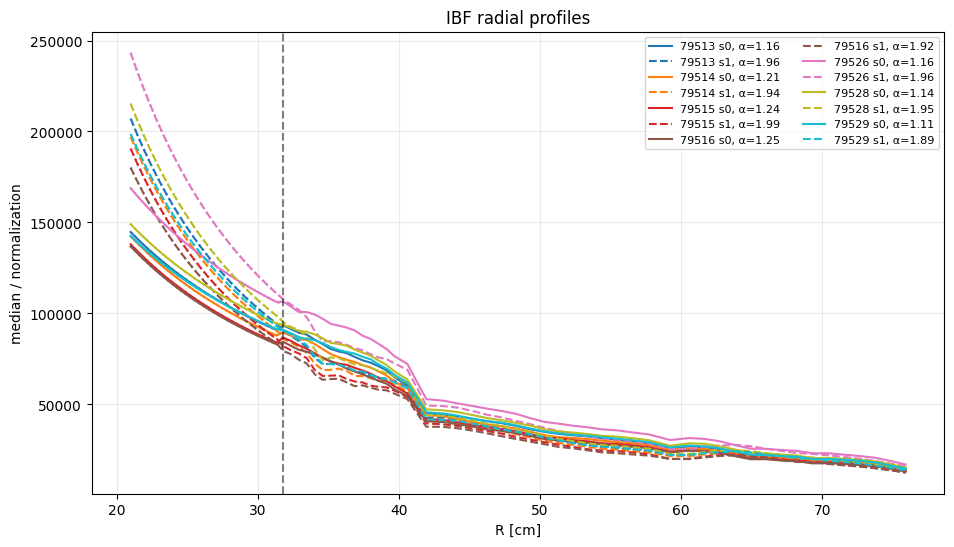

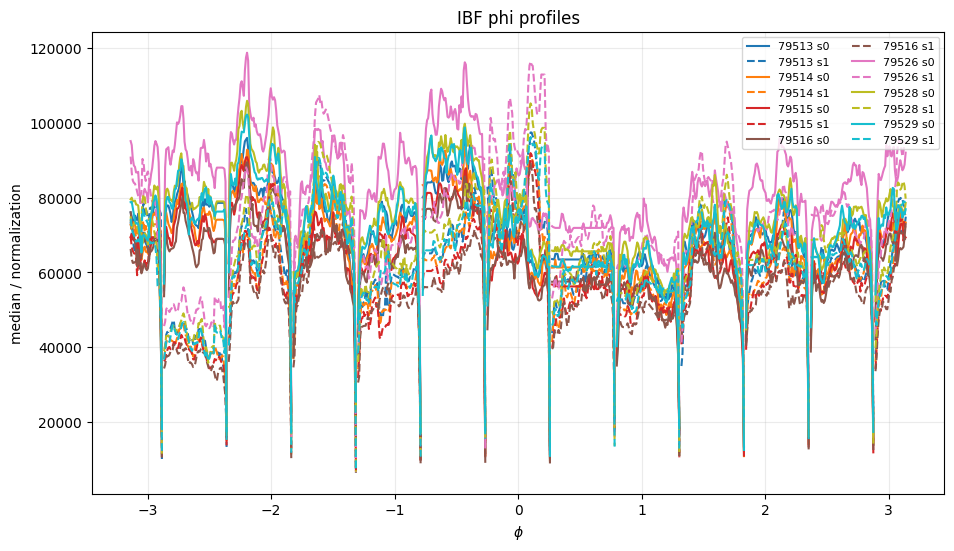

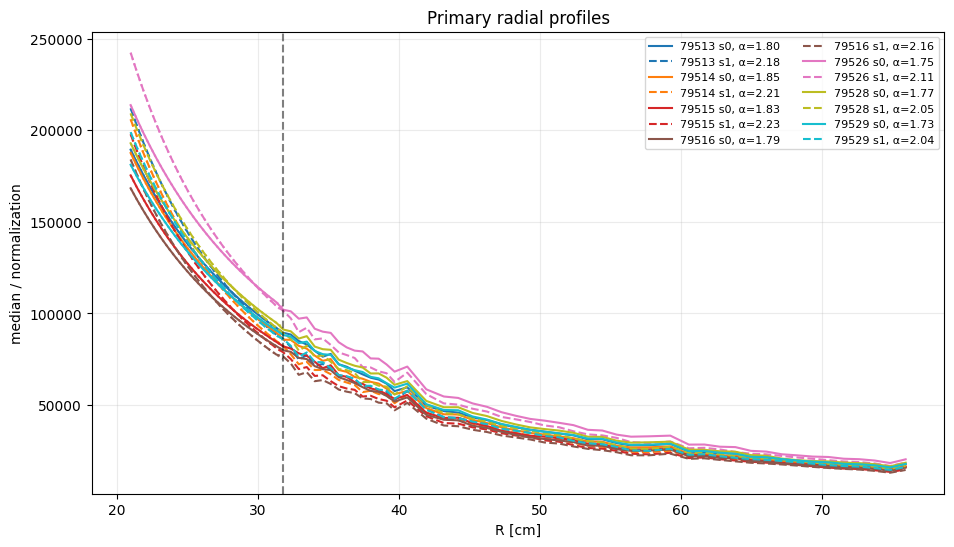

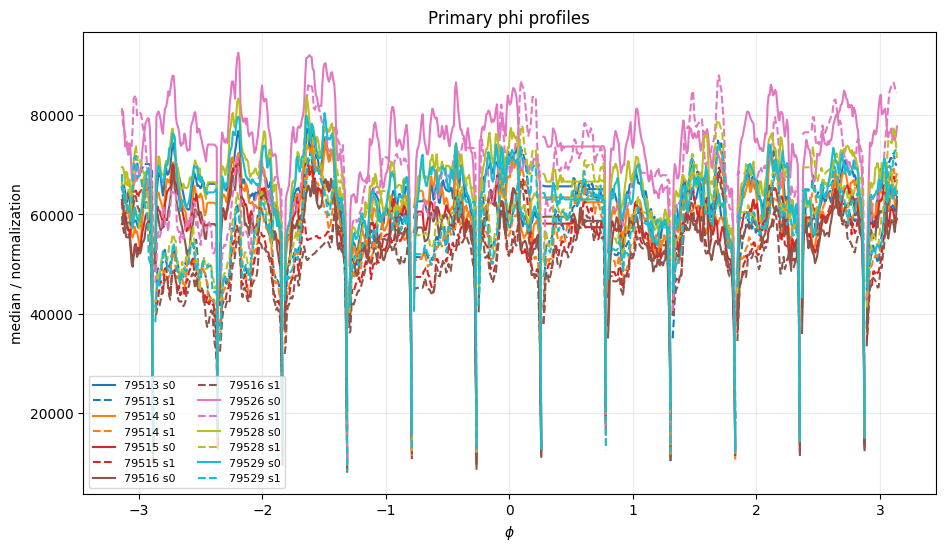

In [18]:
runs=[79513,79514,79515,79516,79526,79528,79529]; norms=[100,100,100,100,100,100,100]
files=[root.TFile.Open(f"output/TPC_IBF_primary_maps_QA1_{r}.root") for r in runs]

def get_profile(f,name):
    h=f.Get(name); nr,np_=h.GetNbinsY(),h.GetNbinsX()
    r=np.array([h.GetYaxis().GetBinCenter(i+1) for i in range(nr)])
    phi=np.array([h.GetXaxis().GetBinCenter(i+1) for i in range(np_)])
    a=np.array([[h.GetBinContent(ip+1,ir+1) for ip in range(np_)] for ir in range(nr)],float)
    a[a<=0]=np.nan
    return r,phi,np.nanmedian(a,axis=1),np.nanmedian(a,axis=0)

def powerfit(r,y,rmax):
    m=np.isfinite(y)&(y>0)&(r<rmax)
    p=np.polyfit(np.log(r[m]),np.log(y[m]),1)
    alpha=-p[0]; A=np.exp(p[1])
    return alpha,A

colors=plt.cm.tab10(np.linspace(0,1,len(runs)))
r1=all_r[0] if "all_r" in globals() else 31.5

# IBF radial
plt.figure(figsize=(11,6))
for f,run,norm,c in zip(files,runs,norms,colors):
    for side,ls in [(0,"-"),(1,"--")]:
        r,phi,pr,pp=get_profile(f,f"h_ibf_final_rphi_side{side}"); pr/=norm
        alpha,A=powerfit(r,pr,r1); plt.plot(r,pr,ls=ls,color=c,label=f"{run} s{side}, α={alpha:.2f}")
        rf=np.linspace(r.min(),r1,100); plt.plot(rf,A/rf**alpha,ls=":",color=c,alpha=0.8)
plt.axvline(r1,ls="--",color="k",alpha=0.5); plt.xlabel("R [cm]"); plt.ylabel("median / normalization"); plt.title("IBF radial profiles"); plt.grid(alpha=0.25); plt.legend(ncol=2,fontsize=8); plt.show()

# IBF phi
plt.figure(figsize=(11,6))
for f,run,norm,c in zip(files,runs,norms,colors):
    for side,ls in [(0,"-"),(1,"--")]:
        r,phi,pr,pp=get_profile(f,f"h_ibf_final_rphi_side{side}"); plt.plot(phi,pp/norm,ls=ls,color=c,label=f"{run} s{side}")
plt.xlabel(r"$\phi$"); plt.ylabel("median / normalization"); plt.title("IBF phi profiles"); plt.grid(alpha=0.25); plt.legend(ncol=2,fontsize=8); plt.show()

# Primary radial
plt.figure(figsize=(11,6))
for f,run,norm,c in zip(files,runs,norms,colors):
    for side,ls in [(0,"-"),(1,"--")]:
        r,phi,pr,pp=get_profile(f,f"h_primary_final_rphi_side{side}"); pr/=norm
        alpha,A=powerfit(r,pr,r1); plt.plot(r,pr,ls=ls,color=c,label=f"{run} s{side}, α={alpha:.2f}")
        rf=np.linspace(r.min(),r1,100); plt.plot(rf,A/rf**alpha,ls=":",color=c,alpha=0.8)
plt.axvline(r1,ls="--",color="k",alpha=0.5); plt.xlabel("R [cm]"); plt.ylabel("median / normalization"); plt.title("Primary radial profiles"); plt.grid(alpha=0.25); plt.legend(ncol=2,fontsize=8); plt.show()

# Primary phi
plt.figure(figsize=(11,6))
for f,run,norm,c in zip(files,runs,norms,colors):
    for side,ls in [(0,"-"),(1,"--")]:
        r,phi,pr,pp=get_profile(f,f"h_primary_final_rphi_side{side}"); plt.plot(phi,pp/norm,ls=ls,color=c,label=f"{run} s{side}")
plt.xlabel(r"$\phi$"); plt.ylabel("median / normalization"); plt.title("Primary phi profiles"); plt.grid(alpha=0.25); plt.legend(ncol=2,fontsize=8); plt.show()

/tmp/ipykernel_64145/1542875555.py:10: RuntimeWarning: All-NaN slice encountered
  return r,phi,np.nanmedian(a,axis=1),np.nanmedian(a,axis=0)


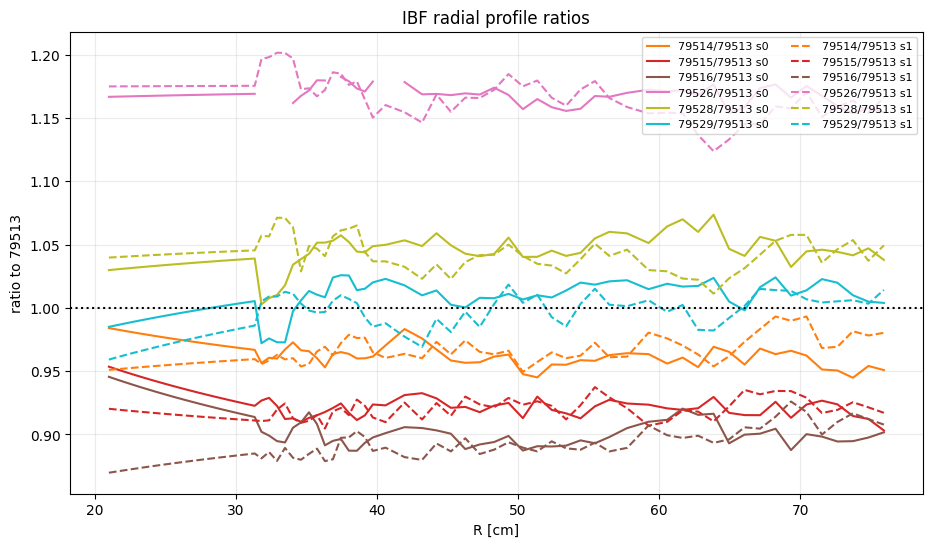

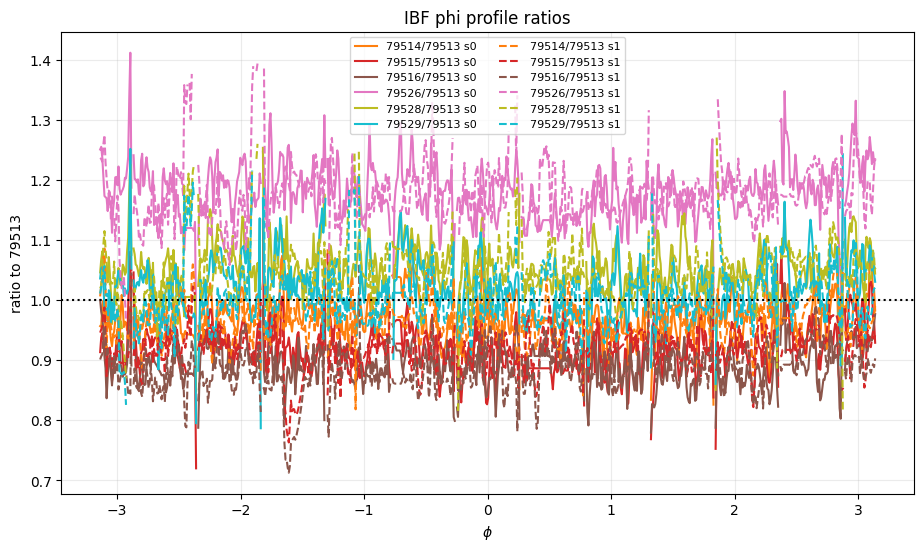

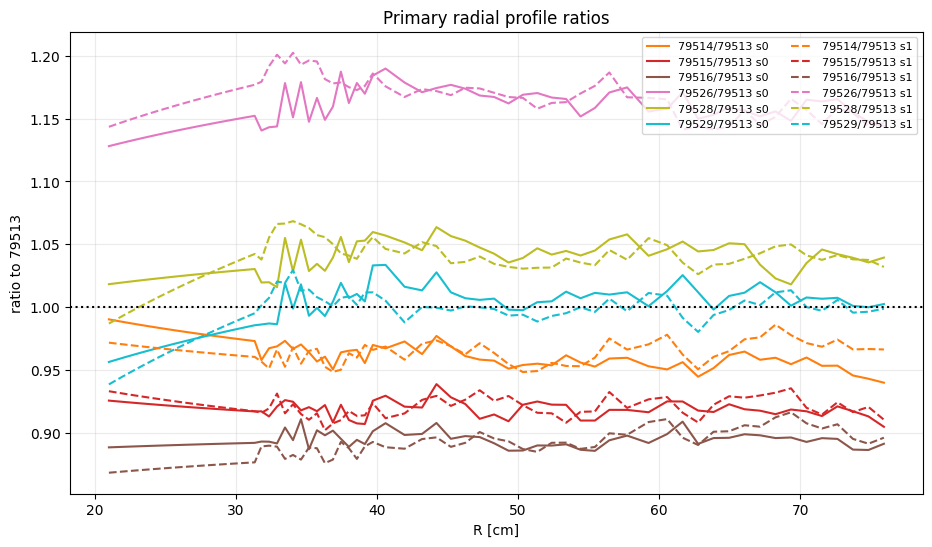

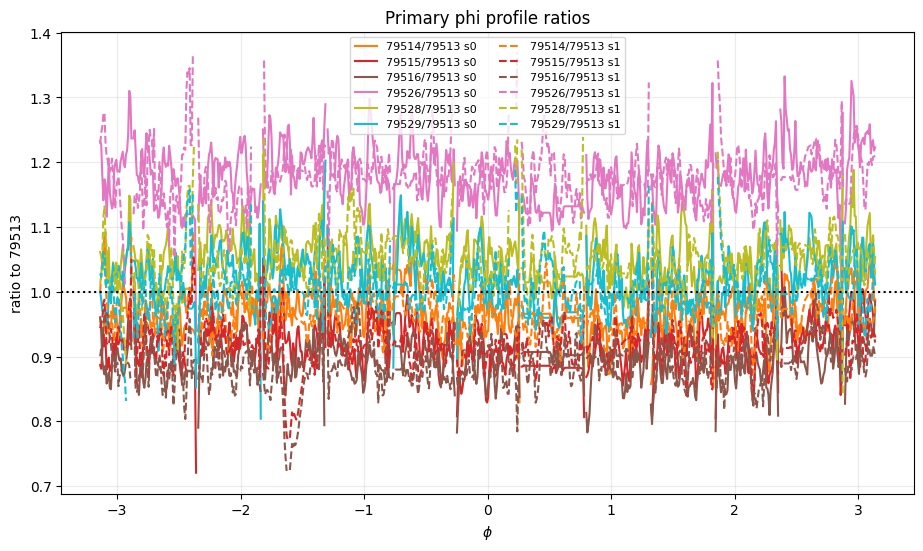

In [19]:
def safe_ratio(y,ref,min_ref_frac=0.05,nmad=6):
    y=np.asarray(y,float); ref=np.asarray(ref,float)
    good=np.isfinite(y)&np.isfinite(ref)&(np.abs(ref)>min_ref_frac*np.nanmedian(np.abs(ref[np.isfinite(ref)])))
    ratio=np.full_like(y,np.nan); ratio[good]=y[good]/ref[good]
    v=ratio[np.isfinite(ratio)]
    if len(v):
        med=np.nanmedian(v); mad=1.4826*np.nanmedian(np.abs(v-med))
        if mad>0: ratio[np.abs(ratio-med)>nmad*mad]=np.nan
    return ratio

ref_run=runs[0]; ref_norm=norms[0]

# IBF radial ratio to first run
plt.figure(figsize=(11,6))
for side,ls in [(0,"-"),(1,"--")]:
    r,phi,ref_r,ref_phi=get_profile(files[0],f"h_ibf_final_rphi_side{side}"); ref_r/=ref_norm
    for f,run,norm,c in zip(files[1:],runs[1:],norms[1:],colors[1:]):
        _,_,pr,_=get_profile(f,f"h_ibf_final_rphi_side{side}"); pr/=norm
        plt.plot(r,safe_ratio(pr,ref_r),ls=ls,color=c,label=f"{run}/{ref_run} s{side}")
plt.axhline(1,ls=":",color="k"); plt.xlabel("R [cm]"); plt.ylabel(f"ratio to {ref_run}"); plt.title("IBF radial profile ratios"); plt.grid(alpha=0.25); plt.legend(ncol=2,fontsize=8); plt.show()

# IBF phi ratio to first run
plt.figure(figsize=(11,6))
for side,ls in [(0,"-"),(1,"--")]:
    r,phi,ref_r,ref_phi=get_profile(files[0],f"h_ibf_final_rphi_side{side}"); ref_phi/=ref_norm
    for f,run,norm,c in zip(files[1:],runs[1:],norms[1:],colors[1:]):
        _,_,_,pp=get_profile(f,f"h_ibf_final_rphi_side{side}"); pp/=norm
        plt.plot(phi,safe_ratio(pp,ref_phi),ls=ls,color=c,label=f"{run}/{ref_run} s{side}")
plt.axhline(1,ls=":",color="k"); plt.xlabel(r"$\phi$"); plt.ylabel(f"ratio to {ref_run}"); plt.title("IBF phi profile ratios"); plt.grid(alpha=0.25); plt.legend(ncol=2,fontsize=8); plt.show()

# Primary radial ratio to first run
plt.figure(figsize=(11,6))
for side,ls in [(0,"-"),(1,"--")]:
    r,phi,ref_r,ref_phi=get_profile(files[0],f"h_primary_final_rphi_side{side}"); ref_r/=ref_norm
    for f,run,norm,c in zip(files[1:],runs[1:],norms[1:],colors[1:]):
        _,_,pr,_=get_profile(f,f"h_primary_final_rphi_side{side}"); pr/=norm
        plt.plot(r,safe_ratio(pr,ref_r),ls=ls,color=c,label=f"{run}/{ref_run} s{side}")
plt.axhline(1,ls=":",color="k"); plt.xlabel("R [cm]"); plt.ylabel(f"ratio to {ref_run}"); plt.title("Primary radial profile ratios"); plt.grid(alpha=0.25); plt.legend(ncol=2,fontsize=8); plt.show()

# Primary phi ratio to first run
plt.figure(figsize=(11,6))
for side,ls in [(0,"-"),(1,"--")]:
    r,phi,ref_r,ref_phi=get_profile(files[0],f"h_primary_final_rphi_side{side}"); ref_phi/=ref_norm
    for f,run,norm,c in zip(files[1:],runs[1:],norms[1:],colors[1:]):
        _,_,_,pp=get_profile(f,f"h_primary_final_rphi_side{side}"); pp/=norm
        plt.plot(phi,safe_ratio(pp,ref_phi),ls=ls,color=c,label=f"{run}/{ref_run} s{side}")
plt.axhline(1,ls=":",color="k"); plt.xlabel(r"$\phi$"); plt.ylabel(f"ratio to {ref_run}"); plt.title("Primary phi profile ratios"); plt.grid(alpha=0.25); plt.legend(ncol=2,fontsize=8); plt.show()

In [20]:
gem_current_north_runs = {79513: 3.14, 79514: 2.97, 79515: 2.80, 79516: 2.70, 79526: 3.70, 79528: 3.47, 79529: 3.26}
gem_current_south_runs = {79513: 3.29, 79514: 3.12, 79515: 2.95, 79516: 2.85, 79526: 3.79, 79528: 3.58, 79529: 3.35}